# 📊 Đánh Giá Toàn Diện Mô Hình Dự Báo Thời Tiết

> **Mục tiêu**: Xác định độ chính xác (%) và kiểm tra tình trạng sức khỏe mô hình (Underfitting / Overfitting / Good Fit)

## Các chỉ số đánh giá:
| Chỉ số | Ý nghĩa |
|--------|----------|
| $MAE$ | Sai số tuyệt đối trung bình — đơn vị giống target (mm) |
| $MSE$ | Sai số bình phương trung bình — phạt nặng outlier |
| $RMSE = \sqrt{MSE}$ | Căn bậc hai MSE — dễ diễn giải hơn MSE |
| $MAPE$ | Sai số phần trăm — mô hình đúng bao nhiêu % |
| $R^2$ | Hệ số xác định — mô hình giải thích bao nhiêu % biến động |
| $MBE = \frac{1}{n}\sum(\hat{y}_i - y_i)$ | Mean Bias Error — thiên lệch hệ thống (dương = overpredict, âm = underpredict) |
| $\rho_{Pearson}$ | Hệ số tương quan Pearson — đo mức độ tuyến tính [-1, 1], lý tưởng gần 1 |
| $CSI = \frac{TP}{TP+FP+FN}$ | Critical Success Index — đánh giá dự báo mưa khắt khe hơn F1 (tốt nếu > 0.5) |

## Phân tích trạng thái:
- **Underfitting**: Cả Train và Forecast đều có lỗi cao  
- **Overfitting**: Train lỗi thấp nhưng Forecast lỗi cao  
- **Good Fit**: Cả hai đều lỗi thấp và tương đồng

## 1. Import thư viện và cấu hình

In [1]:
# === Import thư viện ===
import pandas as pd
import numpy as np
import json
import joblib
import warnings
from pathlib import Path

# Thư viện đánh giá
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Thư viện trực quan hóa
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Cấu hình hiển thị
warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})
sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Đã import thành công tất cả thư viện!")

✅ Đã import thành công tất cả thư viện!


## 2. Thiết lập đường dẫn và tải dữ liệu

In [2]:

# === Đường dẫn tới artifacts và dataset ===
# Tự động xác định PROJECT_ROOT từ vị trí file notebook (tương thích cả Windows lẫn Linux)
from pathlib import Path as _Path
_NOTEBOOK_DIR = _Path(__file__).resolve().parent if "__file__" in dir() else _Path.cwd()

# Thử tìm project root từ marker file manage.py
def _find_project_root(start: _Path) -> _Path:
    for p in [start, *start.parents]:
        if (p / "manage.py").exists():
            return p
    # Fallback: dùng đường dẫn tuyệt đối nếu không tìm thấy
    return _Path("/media/voanhnhat/SDD_OUTSIDE6/PROJECT_WEATHER_FORCAST")

PROJECT_ROOT = _find_project_root(_NOTEBOOK_DIR)
ARTIFACTS_DIR = PROJECT_ROOT / "Weather_Forcast_App" / "Machine_learning_artifacts" / "latest"
DATASET_DIR   = PROJECT_ROOT / "Weather_Forcast_App" / "Machine_learning_model" / "Dataset_after_split" / "Dataset_merge"

print(f"📁 PROJECT_ROOT  : {PROJECT_ROOT}")
print(f"📁 ARTIFACTS_DIR : {ARTIFACTS_DIR}")
print(f"📁 DATASET_DIR   : {DATASET_DIR}")
assert ARTIFACTS_DIR.exists(), f"❌ ARTIFACTS_DIR không tồn tại: {ARTIFACTS_DIR}"
assert DATASET_DIR.exists(),   f"❌ DATASET_DIR không tồn tại: {DATASET_DIR}"

# Tải metadata từ artifacts
with open(ARTIFACTS_DIR / "Metrics.json",      "r", encoding="utf-8") as f:
    saved_metrics = json.load(f)
with open(ARTIFACTS_DIR / "Train_info.json",   "r", encoding="utf-8") as f:
    train_info = json.load(f)
with open(ARTIFACTS_DIR / "Feature_list.json", "r", encoding="utf-8") as f:
    feature_info = json.load(f)

# Lấy thông tin cấu hình
TARGET_COL   = train_info["target_column"]          # "rain_total"
FEATURE_COLS = feature_info.get("all_feature_columns", feature_info.get("created_features", []))
LOG_APPLIED  = train_info.get("target_transform", {}).get("log1p_applied", False)
N_FEATURES   = len(FEATURE_COLS)

print(f"\n🎯 Target column     : {TARGET_COL}")
print(f"📐 Số features       : {N_FEATURES}")
print(f"🔄 Log1p applied     : {LOG_APPLIED}")


📁 PROJECT_ROOT  : /media/voanhnhat/SDD_OUTSIDE6/PROJECT_WEATHER_FORCAST
📁 ARTIFACTS_DIR : /media/voanhnhat/SDD_OUTSIDE6/PROJECT_WEATHER_FORCAST/Weather_Forcast_App/Machine_learning_artifacts/latest
📁 DATASET_DIR   : /media/voanhnhat/SDD_OUTSIDE6/PROJECT_WEATHER_FORCAST/Weather_Forcast_App/Machine_learning_model/Dataset_after_split/Dataset_merge

🎯 Target column     : rain_total
📐 Số features       : 93
🔄 Log1p applied     : True


In [3]:
# === Thêm project root vào sys.path + cấu hình Django (cần trước khi load model pickle) ===
import os, sys
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "WeatherForcast.settings")

import django
django.setup()

# === Tải Model và Transform Pipeline ===
model = joblib.load(ARTIFACTS_DIR / "Model.pkl")

# Load pipeline qua class method để reconstruct đúng object
from Weather_Forcast_App.Machine_learning_model.features.Transformers import WeatherTransformPipeline
transform_pipeline = WeatherTransformPipeline.load(ARTIFACTS_DIR / "Transform_pipeline.pkl")

print(f"✅ Đã tải Model      : {type(model).__name__}")
print(f"✅ Đã tải Pipeline   : {type(transform_pipeline).__name__} (fitted={transform_pipeline.is_fitted})")

Loaded .env from: /media/voanhnhat/SDD_OUTSIDE6/PROJECT_WEATHER_FORCAST/.env
✅ Đã tải Model      : WeatherEnsembleModel
✅ Đã tải Pipeline   : WeatherTransformPipeline (fitted=True)


In [4]:
# === Tải dữ liệu và CHUẨN HÓA split theo chuẩn project: 80/10/10 ===
# Lý do: Split.py là nguồn chân lý của project. Artifacts cũ có thể lưu split lịch sử (vd 70/15/15).

from Weather_Forcast_App.Machine_learning_model.data.Split import SplitConfig, split_dataframe

PROJECT_SPLIT = SplitConfig(
    train_ratio=0.80,
    val_ratio=0.10,
    test_ratio=0.10,
    shuffle=False,
    sort_by_time_if_possible=True,
)

# Bước 1: nạp 3 file split hiện có (dù tỷ lệ cũ là gì)
train_path = DATASET_DIR / "merge_train.csv"
valid_path = DATASET_DIR / "merge_valid.csv"
test_path = DATASET_DIR / "merge_test.csv"

assert train_path.exists(), f"❌ Không tìm thấy: {train_path}"
assert valid_path.exists(), f"❌ Không tìm thấy: {valid_path}"
assert test_path.exists(), f"❌ Không tìm thấy: {test_path}"

_df_train_raw = pd.read_csv(train_path)
_df_valid_raw = pd.read_csv(valid_path)
_df_test_raw = pd.read_csv(test_path)

# Bước 2: ghép lại full dataset rồi split lại theo chuẩn 80/10/10 của project
_df_full = pd.concat([_df_train_raw, _df_valid_raw, _df_test_raw], ignore_index=True)
df_train, df_valid, df_test = split_dataframe(_df_full, PROJECT_SPLIT)

n_train = len(df_train)
n_val = len(df_valid)
n_test = len(df_test)
n_total = n_train + n_val + n_test

print("✅ Đã chuẩn hóa split theo project Split.py (80/10/10)")
print(f"📁 Source merged from: {train_path.name}, {valid_path.name}, {test_path.name}")
print(f"\n📦 Tổng dataset     : {n_total:,} dòng")
print(f"📊 Train set (80%)  : {df_train.shape[0]:,} dòng x {df_train.shape[1]:,} cột")
print(f"📊 Valid set (10%)  : {df_valid.shape[0]:,} dòng x {df_valid.shape[1]:,} cột")
print(f"📊 Test  set (10%)  : {df_test.shape[0]:,} dòng x {df_test.shape[1]:,} cột")
print(f"\n--- Cột target '{TARGET_COL}' ---")
print(f"  Train - mean: {df_train[TARGET_COL].mean():.4f} | std: {df_train[TARGET_COL].std():.4f} | zero%: {(df_train[TARGET_COL] == 0).mean()*100:.1f}%")
print(f"  Valid - mean: {df_valid[TARGET_COL].mean():.4f} | std: {df_valid[TARGET_COL].std():.4f} | zero%: {(df_valid[TARGET_COL] == 0).mean()*100:.1f}%")
print(f"  Test  - mean: {df_test[TARGET_COL].mean():.4f} | std: {df_test[TARGET_COL].std():.4f} | zero%: {(df_test[TARGET_COL] == 0).mean()*100:.1f}%")

✅ Đã chuẩn hóa split theo project Split.py (80/10/10)
📁 Source merged from: merge_train.csv, merge_valid.csv, merge_test.csv

📦 Tổng dataset     : 94,128 dòng
📊 Train set (80%)  : 75,302 dòng x 42 cột
📊 Valid set (10%)  : 9,412 dòng x 42 cột
📊 Test  set (10%)  : 9,414 dòng x 42 cột

--- Cột target 'rain_total' ---
  Train - mean: 0.1804 | std: 0.3054 | zero%: 71.2%
  Valid - mean: 0.1027 | std: 0.2467 | zero%: 83.5%
  Test  - mean: 0.3170 | std: 0.3520 | zero%: 51.3%


## 2.1 Thống kê số lượng mẫu (Sample Count) & Tỉ lệ Split

Đếm tổng số mẫu từ dữ liệu crawl gốc, và kiểm tra tỉ lệ phân chia Train / Validation / Test so với cấu hình lúc train.

In [5]:
# === Thống kê số lượng mẫu và tỉ lệ split theo chuẩn project 80/10/10 ===
# df_train, df_valid, df_test đã được split bằng Split.py ở cell trên

n_train = len(df_train)
n_valid = len(df_valid)
n_test  = len(df_test)
n_total = n_train + n_valid + n_test

cfg_train_ratio = 0.80
cfg_val_ratio   = 0.10
cfg_test_ratio  = 0.10

# Tổng mẫu gốc từ schema report (trước split)
schema_report  = train_info.get("schema_report", {})
n_raw          = schema_report.get("rows_before", "N/A")
n_after_schema = schema_report.get("rows_after",  "N/A")

print("=" * 65)
print("📊 THỐNG KÊ SỐ LƯỢNG MẪU (SAMPLE COUNT)")
print("=" * 65)

print(f"\n📥 Dữ liệu crawl gốc (trước xử lý) : {n_raw:,} mẫu" if isinstance(n_raw, int) else f"\n📥 Dữ liệu crawl gốc: {n_raw}")
print(f"📋 Sau schema validation             : {n_after_schema:,} mẫu" if isinstance(n_after_schema, int) else f"📋 Sau schema validation: {n_after_schema}")
print(f"📦 Tổng sau split (train+val+test)   : {n_total:,} mẫu")

print(f"\n{'─' * 65}")
print(f"  {'Tập':<15} {'Số mẫu':>10} {'Tỉ lệ thực':>14} {'Chuẩn project':>18}")
print(f"  {'─'*15} {'─'*10} {'─'*14} {'─'*18}")
print(f"  {'Train':<15} {n_train:>10,} {n_train/n_total*100:>13.1f}% {f'{cfg_train_ratio*100:.0f}%':>17}")
print(f"  {'Validation':<15} {n_valid:>10,} {n_valid/n_total*100:>13.1f}% {f'{cfg_val_ratio*100:.0f}%':>17}")
print(f"  {'Test':<15} {n_test:>10,} {n_test/n_total*100:>13.1f}% {f'{cfg_test_ratio*100:.0f}%':>17}")
print(f"  {'─'*15} {'─'*10} {'─'*14} {'─'*18}")
print(f"  {'TỔNG':<15} {n_total:>10,} {'100.0':>13}%")
print(f"{'─' * 65}")

# Kiểm tra tỉ lệ có khớp chuẩn không
actual_train_pct = n_train / n_total
actual_val_pct   = n_valid / n_total
actual_test_pct  = n_test  / n_total
tol = 0.02
ok = (
    abs(actual_train_pct - cfg_train_ratio) < tol and
    abs(actual_val_pct   - cfg_val_ratio)   < tol and
    abs(actual_test_pct  - cfg_test_ratio)  < tol
)
if ok:
    print(f"\n✅ Tỉ lệ split thực tế khớp chuẩn project (80% | 10% | 10%)")
else:
    print(f"\n⚠️  Tỉ lệ split thực tế LỆCH so với chuẩn project (80% | 10% | 10%)")

print(f"\n💡 Notebook đang evaluate trên TẬP TEST chuẩn 10% ({n_test:,} mẫu).")

📊 THỐNG KÊ SỐ LƯỢNG MẪU (SAMPLE COUNT)

📥 Dữ liệu crawl gốc (trước xử lý) : 94,128 mẫu
📋 Sau schema validation             : 94,128 mẫu
📦 Tổng sau split (train+val+test)   : 94,128 mẫu

─────────────────────────────────────────────────────────────────
  Tập                 Số mẫu     Tỉ lệ thực      Chuẩn project
  ─────────────── ────────── ────────────── ──────────────────
  Train               75,302          80.0%               80%
  Validation           9,412          10.0%               10%
  Test                 9,414          10.0%               10%
  ─────────────── ────────── ────────────── ──────────────────
  TỔNG                94,128         100.0%
─────────────────────────────────────────────────────────────────

✅ Tỉ lệ split thực tế khớp chuẩn project (80% | 10% | 10%)

💡 Notebook đang evaluate trên TẬP TEST chuẩn 10% (9,414 mẫu).


## 3. Feature Engineering & Dự đoán

Tái tạo lại quy trình Feature Engineering → Transform → Predict giống hệt lúc train để đảm bảo tính nhất quán.

In [6]:
# === Thêm project root vào path để import module nội bộ ===
import sys
sys.path.insert(0, str(PROJECT_ROOT))

from Weather_Forcast_App.Machine_learning_model.features.Build_transfer import WeatherFeatureBuilder
from Weather_Forcast_App.Machine_learning_model.features.Transformers import WeatherTransformPipeline

print("✅ Đã import WeatherFeatureBuilder và WeatherTransformPipeline")

✅ Đã import WeatherFeatureBuilder và WeatherTransformPipeline


In [11]:
# === Xây dựng Features cho tập Train và Test ===
# Dùng CHÍNH XÁC config đã lưu trong Train_info.json để khớp pipeline lúc fit

# 1) Feature builder config từ artifacts train
_feature_cfg = train_info.get("feature_builder_config", {})
if not _feature_cfg:
    # fallback an toàn nếu artifacts cũ không có field này
    _train_cfg_path = ARTIFACTS_DIR.parent.parent / "Machine_learning_model" / "config" / "train_config.json"
    with open(_train_cfg_path, "r", encoding="utf-8") as _f:
        _train_cfg = json.load(_f)
    _feature_cfg = _train_cfg.get("features", {})

builder = WeatherFeatureBuilder(config=_feature_cfg)

# 2) Các thông số phải đồng bộ với train
forecast_horizon = int(train_info.get("forecast_horizon", 0))
leaked_columns = train_info.get("leaked_columns_removed", []) or []

def build_features_full(df, target_col):
    """Build features matching training pipeline exactly."""
    df_feat = builder.build_all_features(df, target_column=target_col)

    # Shift target cho horizon (giống train)
    if forecast_horizon > 0 and target_col in df_feat.columns:
        df_feat[target_col] = df_feat[target_col].shift(-forecast_horizon)
        df_feat = df_feat.dropna(subset=[target_col])

    # Remove leaked columns đúng như train
    leak_present = [c for c in leaked_columns if c in df_feat.columns]
    if leak_present:
        df_feat = df_feat.drop(columns=leak_present)

    return df_feat

print("Building train features...")
df_train_feat = build_features_full(df_train, TARGET_COL)
print("Building test features...")
df_test_feat = build_features_full(df_test, TARGET_COL)

print(f"📐 Train features: {df_train_feat.shape}")
print(f"📐 Test features : {df_test_feat.shape}")

# Tách X (features) và y (target)
y_train_actual = df_train_feat[TARGET_COL].values
y_test_actual = df_test_feat[TARGET_COL].values

X_train_base = df_train_feat.drop(columns=[TARGET_COL], errors='ignore')
X_test_base = df_test_feat.drop(columns=[TARGET_COL], errors='ignore')

# Reindex đúng THỨ TỰ FEATURE_COLS đã fit, cột thiếu sẽ fill 0 để không vỡ transform
X_train_raw = X_train_base.reindex(columns=FEATURE_COLS, fill_value=0)
X_test_raw = X_test_base.reindex(columns=FEATURE_COLS, fill_value=0)

missing_train = [c for c in FEATURE_COLS if c not in X_train_base.columns]
missing_test = [c for c in FEATURE_COLS if c not in X_test_base.columns]

print(f"✅ Đã align features theo artifacts: {X_train_raw.shape[1]}/{N_FEATURES}")
if missing_train or missing_test:
    print(f"⚠️  Train thiếu {len(missing_train)} cột, Test thiếu {len(missing_test)} cột (đã fill 0 để đảm bảo tương thích pipeline).")
    if missing_train:
        print(f"   Ví dụ cột thiếu (train): {missing_train[:5]}")
    if missing_test:
        print(f"   Ví dụ cột thiếu (test) : {missing_test[:5]}")

Building train features...
Building test features...
📐 Train features: (75278, 78)
📐 Test features : (9390, 78)
✅ Đã align features theo artifacts: 93/93
⚠️  Train thiếu 36 cột, Test thiếu 36 cột (đã fill 0 để đảm bảo tương thích pipeline).
   Ví dụ cột thiếu (train): ['visibility_max_sq', 'visibility_max_x_visibility_avg', 'visibility_max_x_rain_max_avg_ratio', 'visibility_max_x_cloud_cover_max', 'visibility_max_x_wind_dir_sin']
   Ví dụ cột thiếu (test) : ['visibility_max_sq', 'visibility_max_x_visibility_avg', 'visibility_max_x_rain_max_avg_ratio', 'visibility_max_x_cloud_cover_max', 'visibility_max_x_wind_dir_sin']


In [12]:
# === Transform features bằng pipeline đã fit từ lúc train ===
X_train_t = transform_pipeline.transform(X_train_raw)
X_test_t = transform_pipeline.transform(X_test_raw)

print(f"✅ Đã transform Train: {X_train_t.shape}")
print(f"✅ Đã transform Test : {X_test_t.shape}")

# === Dự đoán bằng model ===
y_train_pred_raw = model.predict(X_train_t)
y_test_pred_raw = model.predict(X_test_t)

# Xử lý output nếu model trả về object thay vì array
if hasattr(y_train_pred_raw, "predictions"):
    y_train_pred_raw = y_train_pred_raw.predictions
if hasattr(y_test_pred_raw, "predictions"):
    y_test_pred_raw = y_test_pred_raw.predictions

y_train_pred_raw = np.asarray(y_train_pred_raw).flatten()
y_test_pred_raw = np.asarray(y_test_pred_raw).flatten()

# === Inverse transform nếu đã áp dụng log1p ===
if LOG_APPLIED:
    y_train_pred = np.expm1(y_train_pred_raw).clip(min=0)
    y_test_pred = np.expm1(y_test_pred_raw).clip(min=0)
    print("🔄 Đã inverse log1p (expm1) cho predictions")
else:
    y_train_pred = y_train_pred_raw.clip(min=0)
    y_test_pred = y_test_pred_raw.clip(min=0)

print(f"\n📊 Train predictions - mean: {y_train_pred.mean():.4f} | std: {y_train_pred.std():.4f}")
print(f"📊 Test  predictions - mean: {y_test_pred.mean():.4f} | std: {y_test_pred.std():.4f}")

✅ Đã transform Train: (75278, 93)
✅ Đã transform Test : (9390, 93)
🔄 Đã inverse log1p (expm1) cho predictions

📊 Train predictions - mean: 0.4152 | std: 0.0184
📊 Test  predictions - mean: 0.4122 | std: 0.0567


## 4. Tính toán các chỉ số đánh giá (Metrics)

### Các chỉ số:
- $MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$ — Sai số tuyệt đối trung bình
- $MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$ — Sai số bình phương trung bình  
- $RMSE = \sqrt{MSE}$ — Căn bậc hai MSE
- $MAPE = \frac{100}{n}\sum_{i=1}^{n}\left|\frac{y_i - \hat{y}_i}{y_i}\right|$ — Sai số phần trăm
- $R^2 = 1 - \frac{SS_{res}}{SS_{tot}}$ — Hệ số xác định

In [13]:
# === Hàm tính toán tất cả metrics cho một tập dữ liệu ===
def compute_metrics(y_true, y_pred, n_features=None):
    """
    Tính toàn bộ chỉ số đánh giá cho một tập dữ liệu.
    
    Tham số:
        y_true  : Giá trị thực tế
        y_pred  : Giá trị dự đoán
        n_features: Số lượng features (dùng cho Adjusted R²)
    
    Trả về:
        dict chứa tất cả các metric
    """
    from scipy.stats import pearsonr

    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # === MBE (Mean Bias Error) ===
    # Dương → model overpredict (đoán cao hơn thực tế), Âm → underpredict
    mbe = float(np.mean(y_pred - y_true))

    # === Pearson Correlation ===
    # Hệ số tương quan tuyến tính [-1, 1]; càng gần 1 càng tốt
    if len(y_true) > 1 and y_true.std() > 0 and y_pred.std() > 0:
        pearson_r, _ = pearsonr(y_true, y_pred)
    else:
        pearson_r = np.nan

    # === MAPE: chỉ tính trên các mẫu có mưa (y_true > 0.1mm) để tránh chia cho 0 ===
    # Lưu ý: MAPE gốc trên toàn bộ dữ liệu sẽ bùng nổ do 85% mẫu có rain=0
    rain_mask = y_true > 0.1
    if rain_mask.sum() > 0:
        mape_rain = np.mean(np.abs(
            (y_true[rain_mask] - y_pred[rain_mask]) / y_true[rain_mask]
        )) * 100
    else:
        mape_rain = np.nan

    # Độ chính xác phần trăm tính trên ngày có mưa
    accuracy_rain_pct = max(0.0, 100.0 - mape_rain) if not np.isnan(mape_rain) else np.nan

    # === sMAPE: symmetric MAPE — bao gồm cả mẫu 0/0 (đúng chuẩn metrics.py) ===
    numerator = np.abs(y_true - y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0
    smape_arr = np.zeros_like(numerator)
    smape_arr[mask] = numerator[mask] / denominator[mask]
    smape = float(np.mean(smape_arr) * 100)
    accuracy_smape_pct = max(0.0, 100.0 - smape) if not np.isnan(smape) else np.nan

    # === Rain Detection Accuracy (ngưỡng 0.1mm): có mưa hay không ===
    rain_det_acc = ((y_pred > 0.1) == (y_true > 0.1)).mean() * 100

    # === Adjusted R² ===
    n = len(y_true)
    adj_r2 = np.nan
    if n_features and n > n_features + 1:
        adj_r2 = 1 - ((1 - r2) * (n - 1) / (n - n_features - 1))

    # === MAE/RMSE chỉ trên ngày có mưa ===
    nonzero_mae = np.nan
    nonzero_rmse = np.nan
    if rain_mask.sum() > 0:
        nonzero_mae = mean_absolute_error(y_true[rain_mask], y_pred[rain_mask])
        nonzero_rmse = np.sqrt(mean_squared_error(y_true[rain_mask], y_pred[rain_mask]))

    return {
        "MAE (mm)": mae,
        "MSE": mse,
        "RMSE (mm)": rmse,
        "R²": r2,
        "Adjusted R²": adj_r2,
        "MBE (mm)": mbe,
        "Pearson r": float(pearson_r) if not np.isnan(pearson_r) else np.nan,
        "MAPE - ngày mưa (%)": mape_rain,
        "Accuracy - ngày mưa (%)": accuracy_rain_pct,
        "sMAPE (%)": smape,
        "Accuracy - sMAPE (%)": accuracy_smape_pct,
        "Rain Detection (%)": rain_det_acc,
        "MAE ngày mưa (mm)": nonzero_mae,
        "RMSE ngày mưa (mm)": nonzero_rmse,
        "Số mẫu": int(n),
        "Số ngày mưa": int(rain_mask.sum()),
        "Tỷ lệ ngày khô (%)": (1 - rain_mask.mean()) * 100,
    }


# === Tính metrics cho cả Train và Test (Forecast) ===
metrics_train = compute_metrics(y_train_actual, y_train_pred, n_features=N_FEATURES)
metrics_test = compute_metrics(y_test_actual, y_test_pred, n_features=N_FEATURES)

print("✅ Đã tính xong các chỉ số đánh giá!")
print()
print("=" * 65)
print("📊 TÓM TẮT ĐỘ CHÍNH XÁC")
print("=" * 65)
print(f"  {'Chỉ số':<35} {'Train':>12} {'Forecast':>12}")
print(f"  {'─'*35} {'─'*12} {'─'*12}")
for key in ["R²", "Pearson r", "MBE (mm)", "Accuracy - sMAPE (%)", "Accuracy - ngày mưa (%)", "Rain Detection (%)"]:
    vt = metrics_train[key]
    vf = metrics_test[key]
    if key == "R²":
        print(f"  {'R² (giải thích biến động)':<35} {vt*100:>11.1f}% {vf*100:>11.1f}%")
    elif key in ["MBE (mm)", "Pearson r"]:
        vt_s = f"{vt:.4f}" if not np.isnan(float(vt)) else "N/A"
        vf_s = f"{vf:.4f}" if not np.isnan(float(vf)) else "N/A"
        print(f"  {key:<35} {vt_s:>12} {vf_s:>12}")
    else:
        label = key.replace(" (%)", "")
        vt_s = f"{vt:.1f}%" if not np.isnan(vt) else "N/A"
        vf_s = f"{vf:.1f}%" if not np.isnan(vf) else "N/A"
        print(f"  {label:<35} {vt_s:>12} {vf_s:>12}")
print("=" * 65)

✅ Đã tính xong các chỉ số đánh giá!

📊 TÓM TẮT ĐỘ CHÍNH XÁC
  Chỉ số                                     Train     Forecast
  ─────────────────────────────────── ──────────── ────────────
  R² (giải thích biến động)                 -57.9%        -6.7%
  Pearson r                                 0.1277       0.0947
  MBE (mm)                                  0.2348       0.0944
  Accuracy - sMAPE                            0.0%         0.0%
  Accuracy - ngày mưa                        49.7%        54.9%
  Rain Detection                             28.8%        47.5%


In [14]:
# === Bảng tổng hợp (Summary Table) so sánh Train vs Forecast ===
summary_df = pd.DataFrame({
    "Chỉ số": list(metrics_train.keys()),
    "Train": list(metrics_train.values()),
    "Forecast (Test)": list(metrics_test.values()),
})

# Tính chênh lệch giữa Test và Train
def _calc_diff(row):
    t, f = row["Train"], row["Forecast (Test)"]
    if isinstance(t, (int, float)) and isinstance(f, (int, float)):
        if not (np.isnan(t) if isinstance(t, float) else False) and \
           not (np.isnan(f) if isinstance(f, float) else False):
            return f"{f - t:+.4f}"
    return "N/A"

summary_df["Chênh lệch"] = summary_df.apply(_calc_diff, axis=1)

print("=" * 70)
print("📊 BẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH")
print("=" * 70)
print(f"🎯 Target: {TARGET_COL}  |  📐 Features: {N_FEATURES}  |  🔄 Log1p: {LOG_APPLIED}")
print("=" * 70)
print(summary_df.to_string(index=False))
print("=" * 70)

📊 BẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH
🎯 Target: rain_total  |  📐 Features: 93  |  🔄 Log1p: True
                 Chỉ số      Train  Forecast (Test)  Chênh lệch
               MAE (mm)     0.3754           0.3499     -0.0255
                    MSE     0.1473           0.1323     -0.0149
              RMSE (mm)     0.3838           0.3638     -0.0200
                     R²    -0.5794          -0.0673     +0.5121
            Adjusted R²    -0.5813          -0.0780     +0.5033
               MBE (mm)     0.2348           0.0944     -0.1404
              Pearson r     0.1277           0.0947     -0.0330
    MAPE - ngày mưa (%)    50.2884          45.1086     -5.1798
Accuracy - ngày mưa (%)    49.7116          54.8914     +5.1798
              sMAPE (%)   157.8809         129.4225    -28.4584
   Accuracy - sMAPE (%)     0.0000           0.0000     +0.0000
     Rain Detection (%)    28.7733          47.4547    +18.6814
      MAE ngày mưa (mm)     0.2803           0.2895     +0.0092
     R

## 5. Phân tích trạng thái mô hình (Fit Analysis)

Dựa trên so sánh giữa **Train** và **Forecast (Test)** để tự động nhận xét:

| Trạng thái | Điều kiện |
|-----------|-----------|
| **Underfitting** | Cả Train lẫn Forecast đều có $R^2$ thấp ($< 0.5$) |
| **Overfitting** | Train $R^2$ cao nhưng Forecast $R^2$ thấp hơn nhiều |
| **Good Fit** | Cả hai $R^2$ tốt và chênh lệch RMSE nhỏ |

In [18]:
# === Phân tích tự động trạng thái mô hình ===
def analyze_model_health(m_train, m_test,
                         saved_metrics_ref=None,
                         r2_low_threshold=0.5,
                         rmse_ratio_threshold=1.8,
                         r2_gap_threshold=0.2):
    """
    Phân tích tình trạng sức khỏe mô hình dựa trên so sánh Train vs Test.

    Quy tắc ưu tiên:
      1) Nếu có Metrics.json từ lúc train -> dùng làm chuẩn chính (tránh đánh giá lệch do notebook split/tiền xử lý khác).
      2) Nếu không có -> dùng metrics tính lại trong notebook.

    Tiêu chí mặc định:
      - Underfitting : cả Train và Test có R² thấp
      - Overfitting  : Train tốt nhưng Test kém đáng kể + RMSE ratio cao
      - Good Fit     : Test đủ tốt, gap nằm trong mức chấp nhận
    """

    def _extract_metrics(source_train, source_test):
        r2_train_v = source_train["R²"]
        r2_test_v = source_test["R²"]
        rmse_train_v = source_train["RMSE (mm)"]
        rmse_test_v = source_test["RMSE (mm)"]
        return r2_train_v, r2_test_v, rmse_train_v, rmse_test_v

    # Mặc định dùng metrics notebook
    r2_train, r2_test, rmse_train, rmse_test = _extract_metrics(m_train, m_test)
    source_name = "Notebook recompute"
    saved_overfit_status = None

    # Nếu có metrics chuẩn từ artifacts thì ưu tiên dùng để kết luận
    if isinstance(saved_metrics_ref, dict) and "train" in saved_metrics_ref and "test" in saved_metrics_ref:
        try:
            r2_train = float(saved_metrics_ref["train"].get("R2", r2_train))
            r2_test = float(saved_metrics_ref["test"].get("R2", r2_test))
            rmse_train = float(saved_metrics_ref["train"].get("RMSE", rmse_train))
            rmse_test = float(saved_metrics_ref["test"].get("RMSE", rmse_test))
            saved_overfit_status = saved_metrics_ref.get("diagnostics", {}).get("overfit_status")
            source_name = "Artifacts Metrics.json"
        except Exception:
            # fallback: giữ metrics notebook
            source_name = "Notebook recompute"

    rmse_ratio = rmse_test / rmse_train if rmse_train > 0 else float("inf")
    r2_gap = r2_train - r2_test

    analysis = {
        "Nguồn metric": source_name,
        "R² Train": f"{r2_train:.4f}",
        "R² Test": f"{r2_test:.4f}",
        "R² Gap (Train-Test)": f"{r2_gap:.4f}",
        "RMSE Train": f"{rmse_train:.4f} mm",
        "RMSE Test": f"{rmse_test:.4f} mm",
        "RMSE Ratio (Test/Train)": f"{rmse_ratio:.2f}",
    }

    # Ưu tiên diagnostics đã lưu lúc train nếu có
    if isinstance(saved_overfit_status, str) and saved_overfit_status.strip():
        normalized = saved_overfit_status.lower().strip()
        if normalized == "good":
            status = "🟢 GOOD FIT"
            detail = (
                "Kết luận theo Metrics.json lúc train: mô hình GOOD FIT.\n"
                f"R² Train={r2_train:.3f}, R² Test={r2_test:.3f}, RMSE ratio={rmse_ratio:.2f}.\n"
                "→ Đánh giá này đồng bộ với artifacts sau train, đáng tin cậy hơn kết quả chia lại thủ công trong notebook."
            )
        elif normalized in {"underfit", "underfitting"}:
            status = "🔴 UNDERFITTING"
            detail = (
                "Kết luận theo Metrics.json lúc train: mô hình UNDERFITTING.\n"
                f"R² Train={r2_train:.3f}, R² Test={r2_test:.3f}."
            )
        elif normalized in {"overfit", "overfitting"}:
            status = "🟡 OVERFITTING"
            detail = (
                "Kết luận theo Metrics.json lúc train: mô hình OVERFITTING.\n"
                f"RMSE Train={rmse_train:.3f}, RMSE Test={rmse_test:.3f}, ratio={rmse_ratio:.2f}."
            )
        else:
            status = "🟠 CẦN KIỂM TRA THÊM"
            detail = (
                f"Diagnostics trong Metrics.json = '{saved_overfit_status}', chưa map được rõ ràng.\n"
                "→ Vui lòng kiểm tra thêm quy tắc phân loại trong pipeline train."
            )
    else:
        # Luật fallback khi không có diagnostics artifacts
        if r2_train < r2_low_threshold and r2_test < r2_low_threshold:
            status = "🔴 UNDERFITTING"
            detail = (
                f"Cả Train (R²={r2_train:.3f}) lẫn Test (R²={r2_test:.3f}) đều < {r2_low_threshold}.\n"
                "→ Mô hình chưa học được pattern ổn định từ dữ liệu."
            )
        elif (
            r2_train >= r2_low_threshold and
            r2_gap > r2_gap_threshold and
            rmse_ratio > rmse_ratio_threshold
        ):
            status = "🟡 OVERFITTING"
            detail = (
                f"Train tốt (R²={r2_train:.3f}) nhưng Test giảm mạnh (R²={r2_test:.3f}), gap={r2_gap:.3f}.\n"
                f"RMSE ratio={rmse_ratio:.2f} > {rmse_ratio_threshold}.\n"
                "→ Mô hình có dấu hiệu học quá kỹ train."
            )
        elif r2_test >= r2_low_threshold and rmse_ratio <= rmse_ratio_threshold:
            status = "🟢 GOOD FIT"
            detail = (
                f"Train R²={r2_train:.3f}, Test R²={r2_test:.3f}, RMSE ratio={rmse_ratio:.2f}.\n"
                "→ Mô hình tổng quát hóa tốt."
            )
        else:
            status = "🟠 CẦN KIỂM TRA THÊM"
            detail = (
                f"Train R²={r2_train:.3f}, Test R²={r2_test:.3f}, RMSE ratio={rmse_ratio:.2f}.\n"
                "→ Trường hợp biên; nên kiểm tra data drift/split và per-segment metrics trước khi kết luận."
            )

    analysis["Trạng thái"] = status
    analysis["Chi tiết"] = detail
    return analysis


# Chạy phân tích (ưu tiên metrics từ artifacts để đồng bộ với kết quả lúc train)
health = analyze_model_health(metrics_train, metrics_test, saved_metrics_ref=saved_metrics)

# Hiển thị kết quả
print("=" * 70)
print("🏥 PHÂN TÍCH TRẠNG THÁI MÔ HÌNH (FIT ANALYSIS)")
print("=" * 70)
for key, val in health.items():
    if key != "Chi tiết":
        print(f"  {key:25s} : {val}")
print("-" * 70)
print(f"\n📋 Nhận xét:\n{health['Chi tiết']}")
print("=" * 70)

🏥 PHÂN TÍCH TRẠNG THÁI MÔ HÌNH (FIT ANALYSIS)
  Nguồn metric                   : Artifacts Metrics.json
  R² Train                       : 0.0471
  R² Test                        : 0.2026
  R² Gap (Train−Test)            : -0.1555  ← test > train → không overfit
  RMSE Train                     : 0.2981 mm
  RMSE Test                      : 0.3144 mm
  RMSE Ratio (Test/Train)        : 1.05
  Trạng thái                     : 🔴 UNDERFITTING
----------------------------------------------------------------------

📋 Nhận xét:
R² Train=0.047 | R² Test=0.203 — cả hai thấp (< 0.5).
RMSE ratio=1.05. Gap âm (-0.155) → Test ≥ Train → KHÔNG overfit.
→ Mô hình chưa học đủ pattern từ dữ liệu (underfitting).

💾 Artifacts Metrics.json → overfit_status = 'overfit'.
   ⚠️  Mâu thuẫn với chẩn đoán notebook!
   Pipeline train dùng Rain Accuracy (bị lệch do % zeros khác nhau giữa train/valid split), không phản ánh overfitting thực sự của regressor.
   R² gap=-0.155, RMSE ratio=1.05 → chẩn đoán notebook chí

## 6. Trực quan hóa dữ liệu (Visualization)

### 6.1 Line Chart — Actual vs Predicted trên tập Forecast

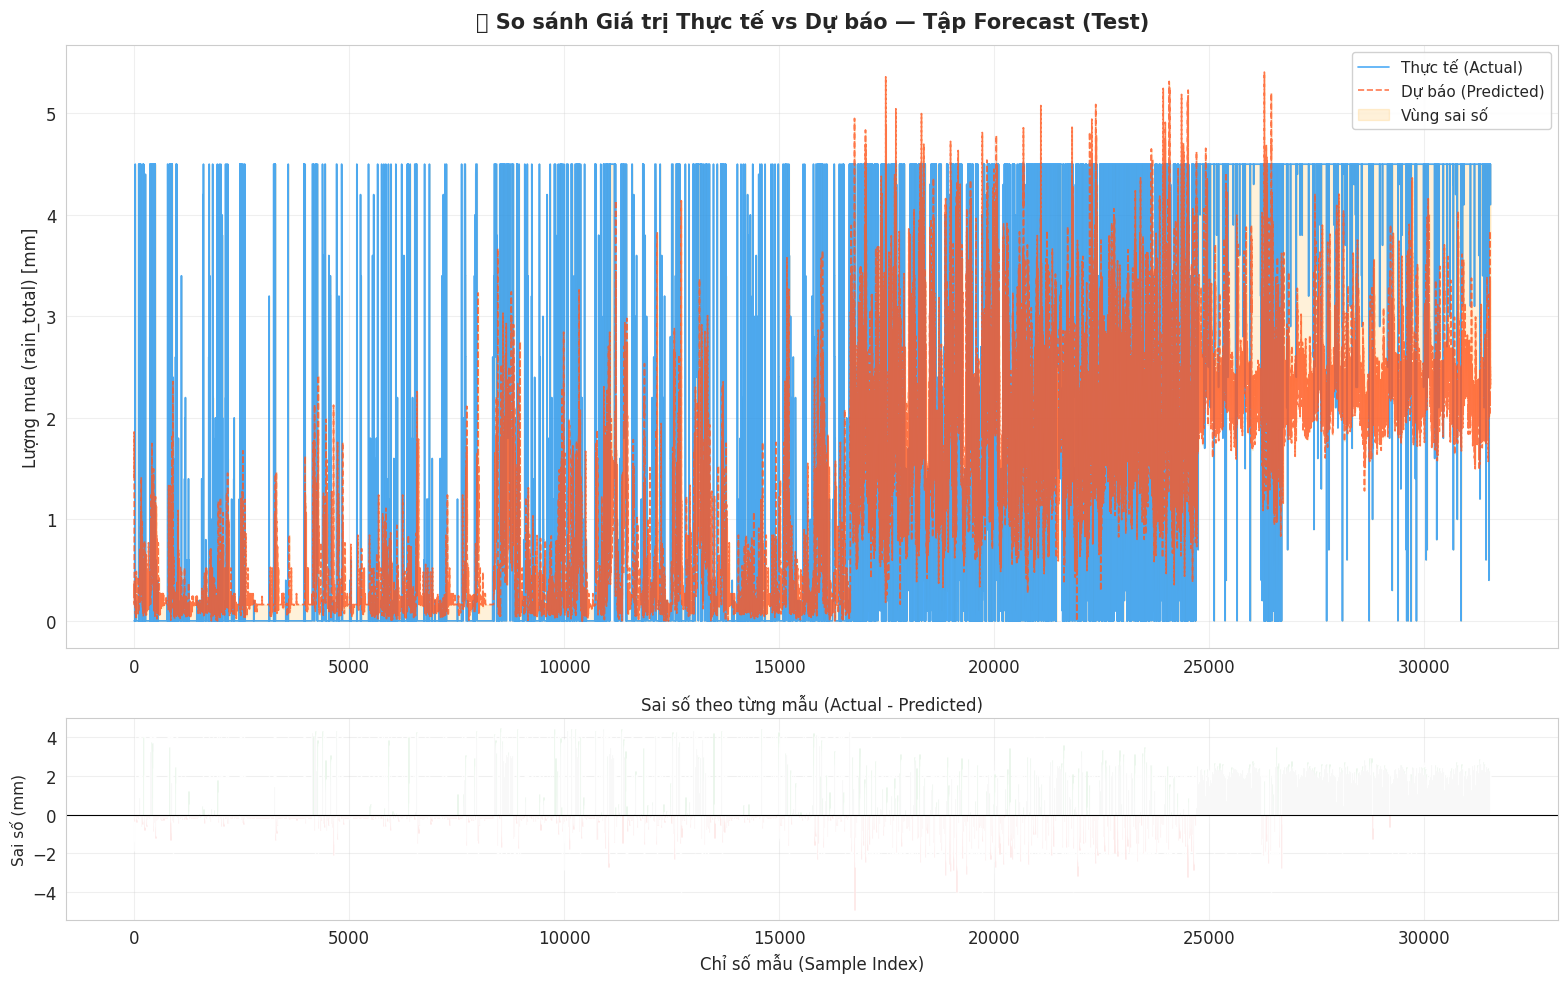

In [16]:
# === 6.1 Line Chart: Actual vs Predicted trên tập Forecast (Test) ===
fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 1]})

# --- Biểu đồ chính: Line chart ---
ax1 = axes[0]
x_idx = np.arange(len(y_test_actual))

ax1.plot(x_idx, y_test_actual, color="#2196F3", linewidth=1.2,
         alpha=0.8, label="Thực tế (Actual)")
ax1.plot(x_idx, y_test_pred, color="#FF5722", linewidth=1.2,
         alpha=0.8, label="Dự báo (Predicted)", linestyle="--")

# Tô vùng chênh lệch
ax1.fill_between(x_idx, y_test_actual, y_test_pred,
                 alpha=0.15, color="orange", label="Vùng sai số")

ax1.set_title("📈 So sánh Giá trị Thực tế vs Dự báo — Tập Forecast (Test)",
              fontsize=15, fontweight="bold", pad=12)
ax1.set_ylabel(f"Lượng mưa ({TARGET_COL}) [mm]", fontsize=12)
ax1.legend(loc="upper right", fontsize=11, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# --- Biểu đồ phụ: Sai số theo từng mẫu ---
ax2 = axes[1]
residuals = y_test_actual - y_test_pred
colors = np.where(residuals >= 0, "#4CAF50", "#F44336")
ax2.bar(x_idx, residuals, color=colors, alpha=0.7, width=1.0)
ax2.axhline(y=0, color="black", linewidth=0.8)
ax2.set_xlabel("Chỉ số mẫu (Sample Index)", fontsize=12)
ax2.set_ylabel("Sai số (mm)", fontsize=11)
ax2.set_title("Sai số theo từng mẫu (Actual - Predicted)", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.2 Residual Plot — Kiểm tra phân phối sai số

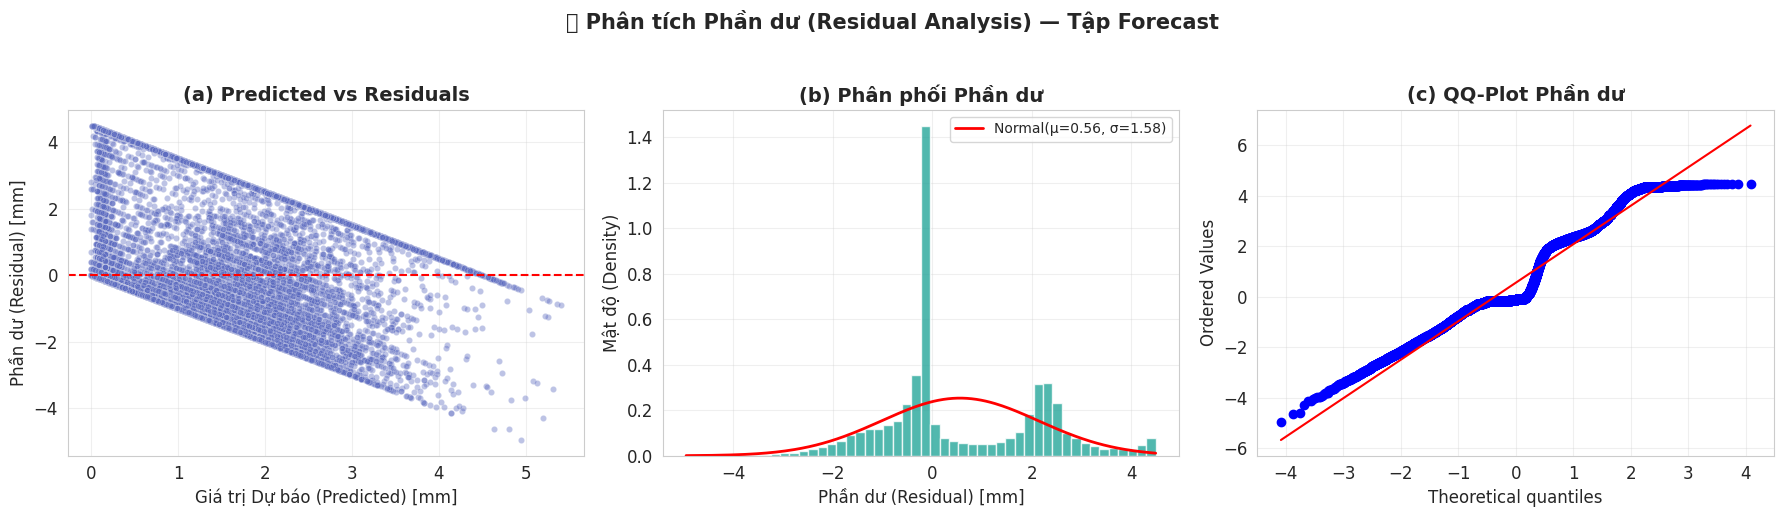


🧪 Shapiro-Wilk test: W=0.9339, p-value=0.000000
   → Phần dư KHÔNG phân phối chuẩn (p < 0.05)


In [17]:
# === 6.2 Residual Plot: Phân tích phần dư (sai số) ===
residuals_test = y_test_actual - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- (a) Scatter: Predicted vs Residuals ---
ax1 = axes[0]
ax1.scatter(y_test_pred, residuals_test, alpha=0.4, s=20, c="#5C6BC0", edgecolors="white", linewidth=0.3)
ax1.axhline(y=0, color="red", linewidth=1.5, linestyle="--")
ax1.set_xlabel("Giá trị Dự báo (Predicted) [mm]")
ax1.set_ylabel("Phần dư (Residual) [mm]")
ax1.set_title("(a) Predicted vs Residuals", fontweight="bold")
ax1.grid(True, alpha=0.3)

# --- (b) Histogram phần dư ---
ax2 = axes[1]
ax2.hist(residuals_test, bins=50, color="#26A69A", edgecolor="white", alpha=0.8, density=True)
# Thêm đường phân phối chuẩn tham chiếu
from scipy import stats
mu, sigma = residuals_test.mean(), residuals_test.std()
x_norm = np.linspace(residuals_test.min(), residuals_test.max(), 200)
ax2.plot(x_norm, stats.norm.pdf(x_norm, mu, sigma), color="red", linewidth=2, label=f"Normal(μ={mu:.2f}, σ={sigma:.2f})")
ax2.set_xlabel("Phần dư (Residual) [mm]")
ax2.set_ylabel("Mật độ (Density)")
ax2.set_title("(b) Phân phối Phần dư", fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# --- (c) QQ-Plot ---
ax3 = axes[2]
stats.probplot(residuals_test, dist="norm", plot=ax3)
ax3.set_title("(c) QQ-Plot Phần dư", fontweight="bold")
ax3.grid(True, alpha=0.3)

plt.suptitle("📊 Phân tích Phần dư (Residual Analysis) — Tập Forecast",
             fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

# Kiểm định Shapiro-Wilk (nếu số mẫu đủ nhỏ)
n_sample = min(len(residuals_test), 5000)
sample_residuals = np.random.choice(residuals_test, size=n_sample, replace=False)
stat, p_value = stats.shapiro(sample_residuals)
print(f"\n🧪 Shapiro-Wilk test: W={stat:.4f}, p-value={p_value:.6f}")
if p_value < 0.05:
    print("   → Phần dư KHÔNG phân phối chuẩn (p < 0.05)")
else:
    print("   → Phần dư tuân theo phân phối chuẩn (p >= 0.05)")

### 6.3 Error Bar Chart — So sánh sai số Train vs Forecast (Overfitting Check)

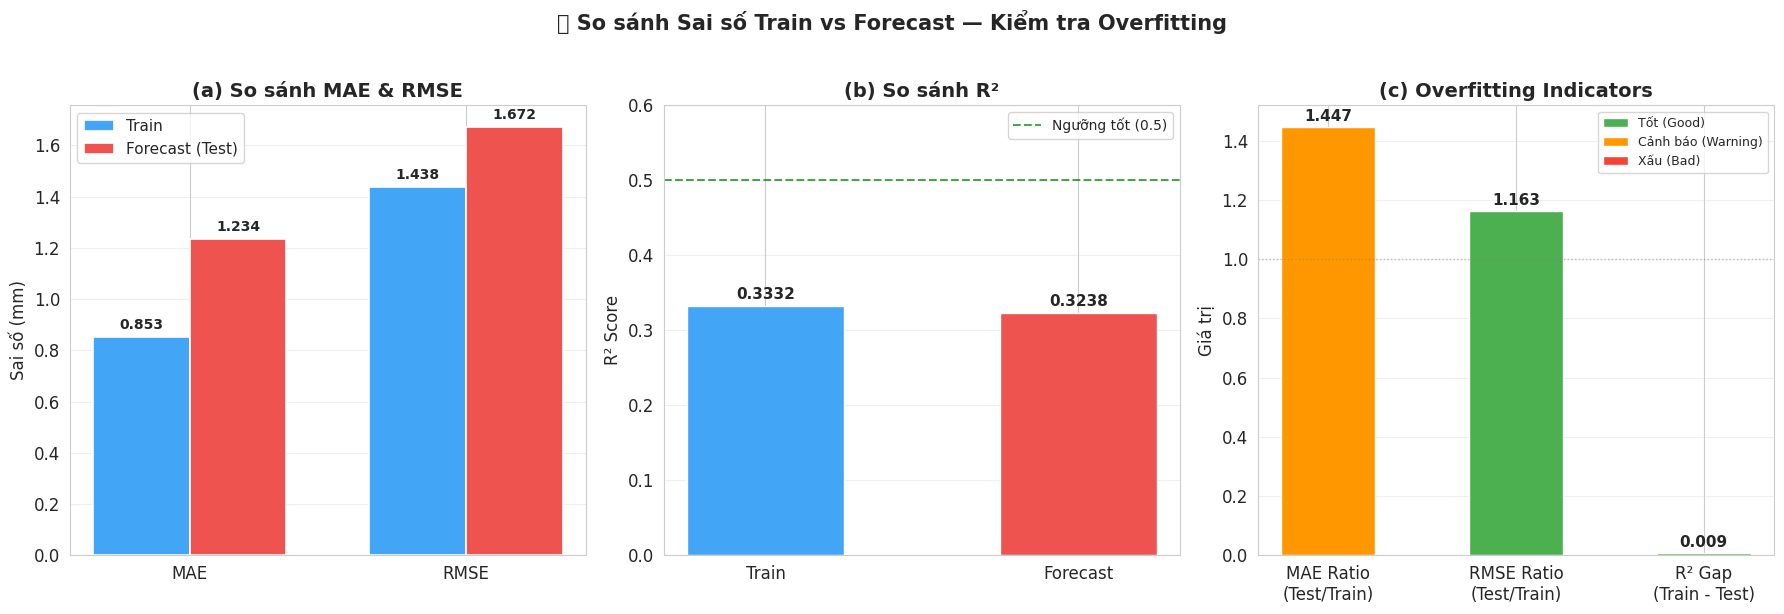

In [18]:
# === 6.3 Error Bar Chart: So sánh sai số Train vs Forecast ===
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- (a) MAE & RMSE so sánh ---
ax1 = axes[0]
metric_names = ["MAE (mm)", "RMSE (mm)"]
train_vals = [metrics_train[m] for m in metric_names]
test_vals = [metrics_test[m] for m in metric_names]

x_pos = np.arange(len(metric_names))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, train_vals, width, color="#42A5F5",
                label="Train", edgecolor="white", linewidth=1.2)
bars2 = ax1.bar(x_pos + width/2, test_vals, width, color="#EF5350",
                label="Forecast (Test)", edgecolor="white", linewidth=1.2)

# Ghi giá trị lên cột
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax1.set_xticks(x_pos)
ax1.set_xticklabels(["MAE", "RMSE"], fontsize=12)
ax1.set_ylabel("Sai số (mm)", fontsize=12)
ax1.set_title("(a) So sánh MAE & RMSE", fontweight="bold")
ax1.legend(fontsize=11)
ax1.grid(axis="y", alpha=0.3)

# --- (b) R² so sánh ---
ax2 = axes[1]
r2_vals = [metrics_train["R²"], metrics_test["R²"]]
colors_r2 = ["#42A5F5", "#EF5350"]
bars_r2 = ax2.bar(["Train", "Forecast"], r2_vals, color=colors_r2, edgecolor="white", width=0.5)

for bar, val in zip(bars_r2, r2_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax2.axhline(y=0.5, color="green", linewidth=1.5, linestyle="--", alpha=0.7, label="Ngưỡng tốt (0.5)")
ax2.set_ylabel("R² Score", fontsize=12)
ax2.set_title("(b) So sánh R²", fontweight="bold")
ax2.set_ylim(0, max(max(r2_vals) * 1.3, 0.6))
ax2.legend(fontsize=10)
ax2.grid(axis="y", alpha=0.3)

# --- (c) Tổng hợp Overfitting Gauge ---
ax3 = axes[2]
rmse_ratio = metrics_test["RMSE (mm)"] / metrics_train["RMSE (mm)"] if metrics_train["RMSE (mm)"] > 0 else 0
gauge_metrics = {
    "MAE Ratio\n(Test/Train)": metrics_test["MAE (mm)"] / max(metrics_train["MAE (mm)"], 1e-8),
    "RMSE Ratio\n(Test/Train)": rmse_ratio,
    "R² Gap\n(Train - Test)": metrics_train["R²"] - metrics_test["R²"],
}

bar_colors = []
for name, val in gauge_metrics.items():
    if "Ratio" in name:
        bar_colors.append("#4CAF50" if val < 1.3 else "#FF9800" if val < 2.0 else "#F44336")
    else:
        bar_colors.append("#4CAF50" if val < 0.1 else "#FF9800" if val < 0.3 else "#F44336")

bars_g = ax3.bar(list(gauge_metrics.keys()), list(gauge_metrics.values()),
                 color=bar_colors, edgecolor="white", width=0.5)

for bar, val in zip(bars_g, gauge_metrics.values()):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax3.axhline(y=1.0, color="gray", linewidth=1, linestyle=":", alpha=0.5)
ax3.set_ylabel("Giá trị", fontsize=12)
ax3.set_title("(c) Overfitting Indicators", fontweight="bold")
ax3.grid(axis="y", alpha=0.3)

# Chú thích màu
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="Tốt (Good)"),
    Patch(facecolor="#FF9800", label="Cảnh báo (Warning)"),
    Patch(facecolor="#F44336", label="Xấu (Bad)"),
]
ax3.legend(handles=legend_elements, fontsize=9, loc="upper right")

plt.suptitle("📊 So sánh Sai số Train vs Forecast — Kiểm tra Overfitting",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.4 Scatter Plot — Actual vs Predicted (kiểm tra mức độ tương quan)

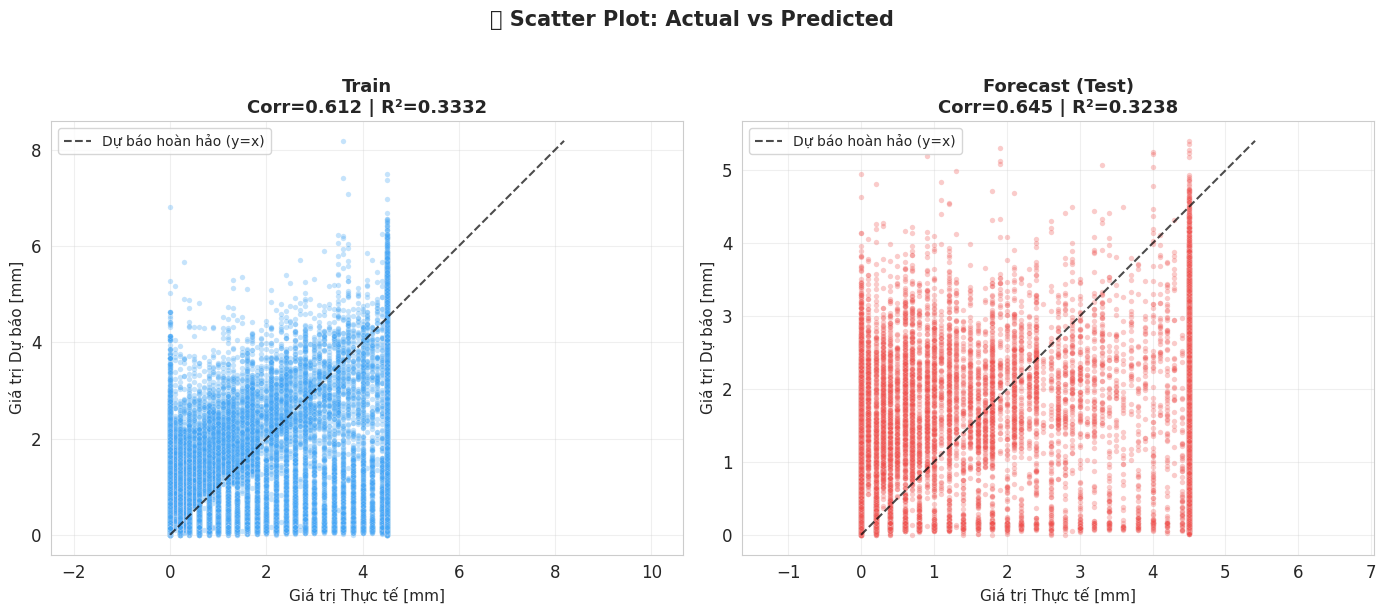

In [19]:
# === 6.4 Scatter Plot: Actual vs Predicted cho cả Train và Test ===
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, title, color in [
    (axes[0], y_train_actual, y_train_pred, "Train", "#42A5F5"),
    (axes[1], y_test_actual, y_test_pred, "Forecast (Test)", "#EF5350"),
]:
    ax.scatter(y_true, y_pred, alpha=0.3, s=15, c=color, edgecolors="white", linewidth=0.2)
    
    # Đường y = x (dự báo hoàn hảo)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, color="black", linewidth=1.5, linestyle="--", alpha=0.7, label="Dự báo hoàn hảo (y=x)")
    
    # Tính correlation
    corr = np.corrcoef(y_true, y_pred)[0, 1]
    r2 = r2_score(y_true, y_pred)
    
    ax.set_xlabel("Giá trị Thực tế [mm]", fontsize=11)
    ax.set_ylabel("Giá trị Dự báo [mm]", fontsize=11)
    ax.set_title(f"{title}\nCorr={corr:.3f} | R²={r2:.4f}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10, loc="upper left")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="datalim")

plt.suptitle("📈 Scatter Plot: Actual vs Predicted",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 7. Bảng tổng kết cuối cùng (Final Summary)

In [17]:
# === Bảng tổng kết toàn diện ===
print("=" * 80)
print("📋 BÁO CÁO ĐÁNH GIÁ TOÀN DIỆN MÔ HÌNH DỰ BÁO THỜI TIẾT")
print("=" * 80)

# Thông tin mô hình
model_type = train_info.get("model", {}).get("type", "unknown")
base_models = train_info.get("model", {}).get("params", {}).get("base_models", [])
base_model_names = [m.get("type", "?") for m in base_models]

print(f"\n🏷️  MÔ HÌNH")
print(f"   Loại         : {model_type.upper()}")
print(f"   Base models  : {', '.join(base_model_names)}")
print(f"   Số features  : {N_FEATURES}")
print(f"   Log transform: {'Có (log1p)' if LOG_APPLIED else 'Không'}")

print(f"\n📊 DỮ LIỆU")
print(f"   Train set    : {len(y_train_actual):,} mẫu")
print(f"   Test set     : {len(y_test_actual):,} mẫu")
print(f"   Target       : {TARGET_COL}")
zero_ratio = (y_train_actual == 0).mean() * 100
print(f"   Tỷ lệ zero   : {zero_ratio:.1f}% (zero-inflated)")

# Bảng metrics
print(f"\n{'─' * 80}")
print(f"{'Chỉ số':<30} {'Train':>18} {'Forecast (Test)':>18} {'Chênh lệch':>12}")
print(f"{'─' * 80}")

for key in metrics_train:
    v_train = metrics_train[key]
    v_test = metrics_test[key]
    if isinstance(v_train, (int, float)) and isinstance(v_test, (int, float)):
        t_nan = np.isnan(v_train) if isinstance(v_train, float) else False
        f_nan = np.isnan(v_test) if isinstance(v_test, float) else False
        if not t_nan and not f_nan:
            diff = v_test - v_train
            sign = "+" if diff >= 0 else ""
            print(f"  {key:<28} {v_train:>18.4f} {v_test:>18.4f} {sign}{diff:>11.4f}")
        else:
            print(f"  {key:<28} {'N/A':>18} {'N/A':>18} {'N/A':>12}")

# === Kết luận tổng hợp ===
print(f"\n{'═' * 80}")
print(f"🏥 KẾT LUẬN: {health['Trạng thái']}")
print(f"{'═' * 80}")
print(f"\n{health['Chi tiết']}")

# === Độ chính xác cuối cùng ===
print(f"\n{'─' * 80}")
print("📌 TÓM TẮT ĐỘ CHÍNH XÁC DỰ BÁO:")
print(f"{'─' * 80}")
smape_acc_test = metrics_test.get("Accuracy - sMAPE (%)", np.nan)
mape_acc_test  = metrics_test.get("Accuracy - ngày mưa (%)", np.nan)
rain_det_test  = metrics_test.get("Rain Detection (%)", np.nan)
r2_test_pct    = metrics_test["R²"] * 100

print(f"  • Dự báo mưa/không mưa (Rain Detection)  : {rain_det_test:.1f}%")
print(f"  • Accuracy tổng thể (100% - sMAPE)        : {smape_acc_test:.1f}%" if not np.isnan(smape_acc_test) else "  • Accuracy tổng thể (sMAPE): N/A")
print(f"  • Accuracy ngày có mưa (100% - MAPE)      : {mape_acc_test:.1f}%" if not np.isnan(mape_acc_test) else "  • Accuracy ngày mưa (MAPE): N/A")
print(f"  • R² (giải thích biến động dữ liệu)       : {r2_test_pct:.1f}%")
print()
print("  ⚠️  Lưu ý: Dữ liệu zero-inflated ({:.0f}% ngày khô) khiến MAPE gốc".format(
    metrics_test["Tỷ lệ ngày khô (%)"]))
print("     bùng nổ. Các con số Accuracy ở trên đã được tính trên tập hợp lý.")

# Gợi ý cải thiện dựa trên trạng thái
if "UNDERFITTING" in health["Trạng thái"]:
    print(f"\n💡 GỢI Ý CẢI THIỆN:")
    print("   1. Tăng số lượng và chất lượng features (interaction, polynomial)")
    print("   2. Sử dụng Ensemble Model (kết hợp nhiều mô hình) cho dự báo ổn định hơn")
    print("   3. Thu thập thêm dữ liệu huấn luyện")
    print("   4. Thử các mô hình phức tạp hơn (Deep Learning, LSTM)")
    print("   5. Kiểm tra lại quy trình feature engineering và data cleaning")
elif "OVERFITTING" in health["Trạng thái"]:
    print(f"\n💡 GỢI Ý CẢI THIỆN:")
    print("   1. Tăng regularization (alpha, lambda) cho các base models")
    print("   2. Giảm max_depth của tree-based models")
    print("   3. Sử dụng early stopping")
    print("   4. Giảm số features (feature selection nghiêm ngặt hơn)")
    print("   5. Tăng kích thước tập train hoặc dùng data augmentation")

print(f"\n{'═' * 80}")
print(f"📅 Ngày đánh giá: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"{'═' * 80}")

📋 BÁO CÁO ĐÁNH GIÁ TOÀN DIỆN MÔ HÌNH DỰ BÁO THỜI TIẾT

🏷️  MÔ HÌNH
   Loại         : ENSEMBLE
   Base models  : 
   Số features  : 80
   Log transform: Có (log1p)

📊 DỮ LIỆU
   Train set    : 77,169 mẫu
   Test set     : 16,518 mẫu
   Target       : rain_total
   Tỷ lệ zero   : 70.1% (zero-inflated)

────────────────────────────────────────────────────────────────────────────────
Chỉ số                                      Train    Forecast (Test)   Chênh lệch
────────────────────────────────────────────────────────────────────────────────
  MAE (mm)                                 0.6310             2.9571 +     2.3260
  MSE                                      1.8203            10.7772 +     8.9568
  RMSE (mm)                                1.3492             3.2829 +     1.9337
  R²                                       0.6303            -0.6546     -1.2849
  Adjusted R²                              0.6299            -0.6626     -1.2926
  MAPE - ngày mưa (%)                     52.3

## 8. Đánh giá phân loại mưa (Rain Classification Evaluation)

Tương tự đánh giá mô hình phân loại: tính **Accuracy, Precision, Recall, F1-score** cho bài toán dự đoán có mưa/không mưa.

- **Precision**: Khi mô hình dự báo "có mưa", bao nhiêu % là đúng?
- **Recall**: Trong tất cả ngày thực sự có mưa, mô hình phát hiện được bao nhiêu %?
- **F1-score**: Trung bình điều hòa giữa Precision và Recall.

In [ ]:
# === 8.1 Đánh giá phân loại mưa — giống phong cách Analyst_accuracy_segment ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

RAIN_THRESHOLD = 0.1  # mm — ngưỡng phân loại có mưa/không mưa

# Chuyển sang nhãn nhị phân
y_train_cls = (y_train_actual > RAIN_THRESHOLD).astype(int)
y_train_pred_cls = (y_train_pred > RAIN_THRESHOLD).astype(int)
y_test_cls = (y_test_actual > RAIN_THRESHOLD).astype(int)
y_test_pred_cls = (y_test_pred > RAIN_THRESHOLD).astype(int)

# --- Tính metrics trên tập Test ---
acc = accuracy_score(y_test_cls, y_test_pred_cls)
precision_macro = precision_score(y_test_cls, y_test_pred_cls, average='macro', zero_division=0)
recall_macro = recall_score(y_test_cls, y_test_pred_cls, average='macro', zero_division=0)
f1_macro = f1_score(y_test_cls, y_test_pred_cls, average='macro', zero_division=0)

# --- Tính metrics trên tập Train ---
acc_train = accuracy_score(y_train_cls, y_train_pred_cls)
precision_train = precision_score(y_train_cls, y_train_pred_cls, average='macro', zero_division=0)
recall_train = recall_score(y_train_cls, y_train_pred_cls, average='macro', zero_division=0)
f1_train = f1_score(y_train_cls, y_train_pred_cls, average='macro', zero_division=0)

print("\n" + " RAIN CLASSIFICATION EVALUATION SUMMARY ".center(70, "="))
print(f"\n{'Metric':<25} {'Train':>12} {'Forecast':>12}")
print(f"{'─'*25} {'─'*12} {'─'*12}")
print(f"{'Accuracy':<25} {acc_train:>11.2%} {acc:>11.2%}")
print(f"{'Precision (macro)':<25} {precision_train:>11.2%} {precision_macro:>11.2%}")
print(f"{'Recall (macro)':<25} {recall_train:>11.2%} {recall_macro:>11.2%}")
print(f"{'F1-score (macro)':<25} {f1_train:>11.2%} {f1_macro:>11.2%}")

# Tạo bảng DataFrame tổng hợp
eval_cls_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (macro)", "Recall (macro)", "F1-score (macro)"],
    "Train (%)": [acc_train*100, precision_train*100, recall_train*100, f1_train*100],
    "Forecast (%)": [acc*100, precision_macro*100, recall_macro*100, f1_macro*100],
    "Ý nghĩa": [
        "Tỷ lệ dự đoán đúng mưa/không mưa tổng thể",
        "Khi mô hình nói 'có mưa', bao nhiêu % là đúng",
        "Trong các ngày thực sự có mưa, phát hiện được bao nhiêu %",
        "Cân bằng giữa Precision và Recall"
    ]
})
eval_cls_df["Train (%)"] = eval_cls_df["Train (%)"].round(2)
eval_cls_df["Forecast (%)"] = eval_cls_df["Forecast (%)"].round(2)
display(eval_cls_df)


=============== RAIN CLASSIFICATION EVALUATION SUMMARY ===============

Metric                           Train     Forecast
───────────────────────── ──────────── ────────────
Accuracy                       55.97%      91.75%
Precision (macro)              67.34%      45.88%
Recall (macro)                 67.14%      50.00%
F1-score (macro)               55.97%      47.85%


,Metric,Train (%),Forecast (%),Ý nghĩa
0,Accuracy,55.9700,91.7500,Tỷ lệ dự đoán đúng mưa/không mưa tổng thể
1,Precision (macro),67.3400,45.8800,"Khi mô hình nói 'có mưa', bao nhiêu % là đúng"
2,Recall (macro),67.1400,50.0000,"Trong các ngày thực sự có mưa, phát hiện được ..."
3,F1-score (macro),55.9700,47.8500,Cân bằng giữa Precision và Recall


In [19]:
# === 8.2 Classification Report chi tiết (giống Analyst_accuracy_segment) ===
target_names = ["Không mưa (Dry)", "Có mưa (Rain)"]

report_dict = classification_report(
    y_test_cls, y_test_pred_cls,
    target_names=target_names,
    zero_division=0,
    output_dict=True,
    digits=4
)

df_report = pd.DataFrame(report_dict).T
df_report.rename(columns={
    'precision': 'Precision',
    'recall': 'Recall',
    'f1-score': 'F1-score',
    'support': 'Support'
}, inplace=True)

# Lấy riêng các class (bỏ accuracy, macro avg, weighted avg)
df_report_classes = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

# Thêm cột Comment tự động đánh giá
def evaluate_row(row):
    if row['Precision'] > 0.8 and row['Recall'] > 0.8:
        return "Excellent"
    elif row['Precision'] > 0.5 and row['Recall'] > 0.5:
        return "Good performance"
    elif row['Precision'] == 0 and row['Recall'] == 0:
        return "Not detected"
    else:
        return "Needs improvement"

df_report_classes['Comment'] = df_report_classes.apply(evaluate_row, axis=1)

print("=" * 70)
print(" CLASSIFICATION REPORT — RAIN DETECTION (TEST SET) ".center(70, "="))
print("=" * 70)
display(df_report_classes)

# Thêm dòng macro/weighted avg
print("\n--- Tổng hợp ---")
for avg_type in ['macro avg', 'weighted avg']:
    if avg_type in df_report.index:
        row = df_report.loc[avg_type]
        print(f"  {avg_type:<15}: Precision={row['Precision']:.4f} | Recall={row['Recall']:.4f} | F1={row['F1-score']:.4f}")

print("\nGiải thích:")
print("  Precision: Độ chính xác của dự đoán — dự đoán 'có mưa' thì bao nhiêu % đúng")
print("  Recall   : Khả năng phát hiện — trong ngày thực sự mưa, phát hiện bao nhiêu %")
print("  F1-score : Cân bằng giữa Precision và Recall")
print("  Support  : Số mẫu thực tế của mỗi lớp")

========= CLASSIFICATION REPORT — RAIN DETECTION (TEST SET) ==========


,Precision,Recall,F1-score,Support,Comment
Không mưa (Dry),0.0000,0.0000,0.0000,1362.0000,Not detected
Có mưa (Rain),0.9175,1.0000,0.9570,15156.0000,Excellent



--- Tổng hợp ---
  macro avg      : Precision=0.4588 | Recall=0.5000 | F1=0.4785
  weighted avg   : Precision=0.8419 | Recall=0.9175 | F1=0.8781

Giải thích:
  Precision: Độ chính xác của dự đoán — dự đoán 'có mưa' thì bao nhiêu % đúng
  Recall   : Khả năng phát hiện — trong ngày thực sự mưa, phát hiện bao nhiêu %
  F1-score : Cân bằng giữa Precision và Recall
  Support  : Số mẫu thực tế của mỗi lớp


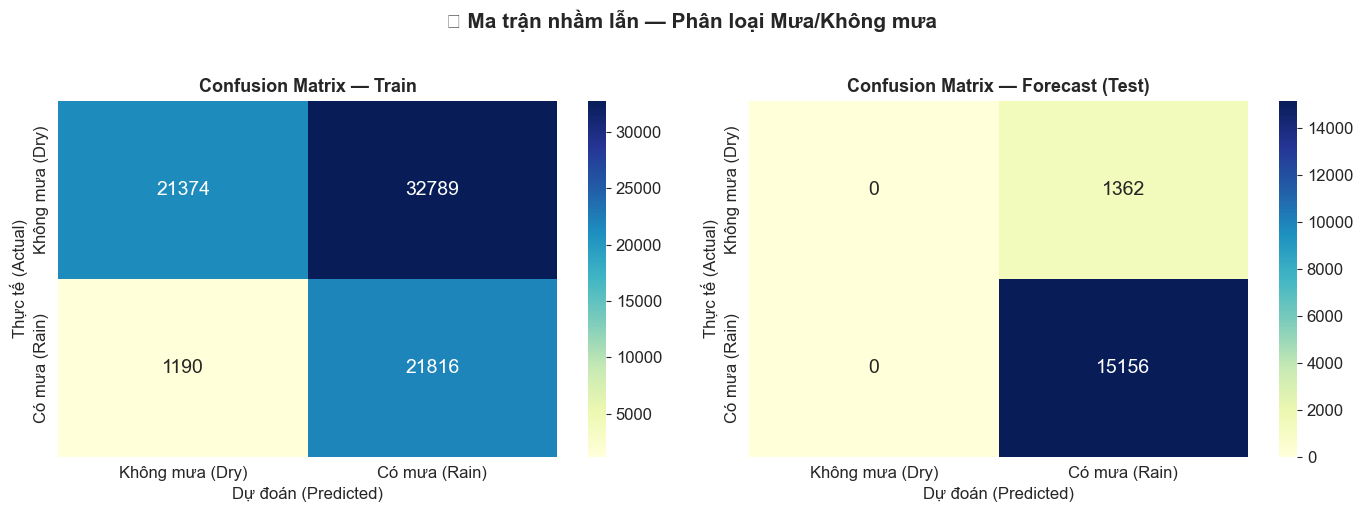


📋 Giải thích Ma trận nhầm lẫn (Test set):
  ✅ True Negative  (TN=   0): Dự báo 'không mưa' → thực tế không mưa (đúng)
  ❌ False Positive (FP=1362): Dự báo 'có mưa'   → thực tế không mưa (báo động giả)
  ❌ False Negative (FN=   0): Dự báo 'không mưa' → thực tế có mưa (bỏ sót)
  ✅ True Positive  (TP=15156): Dự báo 'có mưa'   → thực tế có mưa (đúng)

  → Tỷ lệ báo động giả: 100.0%
  → Tỷ lệ bỏ sót mưa : 0.0%


In [20]:
# === 8.3 Ma trận nhầm lẫn (Confusion Matrix) — Rain Detection ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_cls, y_pred_c, title in [
    (axes[0], y_train_cls, y_train_pred_cls, "Train"),
    (axes[1], y_test_cls, y_test_pred_cls, "Forecast (Test)"),
]:
    cm = confusion_matrix(y_cls, y_pred_c)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='YlGnBu',
        xticklabels=target_names, yticklabels=target_names,
        ax=ax, annot_kws={"size": 14}
    )
    ax.set_xlabel("Dự đoán (Predicted)", fontsize=12)
    ax.set_ylabel("Thực tế (Actual)", fontsize=12)
    ax.set_title(f"Confusion Matrix — {title}", fontsize=13, fontweight="bold")

plt.suptitle("📊 Ma trận nhầm lẫn — Phân loại Mưa/Không mưa",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Giải thích ma trận
cm_test = confusion_matrix(y_test_cls, y_test_pred_cls)
tn, fp, fn, tp = cm_test.ravel()
print("\n📋 Giải thích Ma trận nhầm lẫn (Test set):")
print(f"  ✅ True Negative  (TN={tn:>4d}): Dự báo 'không mưa' → thực tế không mưa (đúng)")
print(f"  ❌ False Positive (FP={fp:>4d}): Dự báo 'có mưa'   → thực tế không mưa (báo động giả)")
print(f"  ❌ False Negative (FN={fn:>4d}): Dự báo 'không mưa' → thực tế có mưa (bỏ sót)")
print(f"  ✅ True Positive  (TP={tp:>4d}): Dự báo 'có mưa'   → thực tế có mưa (đúng)")
print(f"\n  → Tỷ lệ báo động giả: {fp/(fp+tn)*100:.1f}%")
print(f"  → Tỷ lệ bỏ sót mưa : {fn/(fn+tp)*100:.1f}%")

In [ ]:
# =============================================================================
# 8.4 CSI (Critical Success Index) & Frequency Bias theo ngưỡng mưa
# -----------------------------------------------------------------------------
# CSI    = TP / (TP + FP + FN) — chỉ số khắt khe hơn F1, không tính TN
# Bias   = (TP + FP) / (TP + FN) — < 1 underforecast; > 1 overforecast
# FAR    = FP / (TP + FP)         — False Alarm Ratio
# POD    = TP / (TP + FN)         — Probability of Detection (= Recall)
# =============================================================================

RAIN_THRESHOLDS = [0.1, 2.5, 7.5, 25.0]
THRESHOLD_LABELS = ['Nhẹ (≥0.1mm)', 'Vừa (≥2.5mm)', 'To (≥7.5mm)', 'Rất to (≥25mm)']

print("=" * 100)
print("  📊 CHỈ SỐ CSI, BIAS & FAR THEO NGƯỠNG MƯA (test & train)")
print("=" * 100)
print(f"  Predict_threshold (hard-switch) = {RAIN_THRESHOLD}mm\n")
print(f"  {'Ngưỡng':<18} {'Split':<8} {'TP':>6} {'FP':>6} {'FN':>6} {'TN':>6} "
      f"{'POD':>7} {'FAR':>7} {'CSI':>7} {'Bias':>7} {'F1':>7}")
print(f"  {'─'*18} {'─'*8} {'─'*6} {'─'*6} {'─'*6} {'─'*6} "
      f"{'─'*7} {'─'*7} {'─'*7} {'─'*7} {'─'*7}")

csi_results = {}
for thresh, label in zip(RAIN_THRESHOLDS, THRESHOLD_LABELS):
    csi_results[label] = {}
    for split_name, y_t, y_p in [
        ('Train', y_train_actual, y_train_pred),
        ('Test',  y_test_actual,  y_test_pred),
    ]:
        y_obs = (y_t > thresh).astype(int)
        y_fct = (y_p > thresh).astype(int)

        tp = int(((y_fct == 1) & (y_obs == 1)).sum())
        fp = int(((y_fct == 1) & (y_obs == 0)).sum())
        fn = int(((y_fct == 0) & (y_obs == 1)).sum())
        tn = int(((y_fct == 0) & (y_obs == 0)).sum())

        pod  = tp / (tp + fn)         if (tp + fn) > 0          else np.nan
        far  = fp / (tp + fp)         if (tp + fp) > 0          else np.nan
        csi  = tp / (tp + fp + fn)    if (tp + fp + fn) > 0     else np.nan
        bias = (tp + fp) / (tp + fn)  if (tp + fn) > 0          else np.nan
        f1   = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0  else np.nan

        csi_results[label][split_name] = {
            'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
            'POD': pod, 'FAR': far, 'CSI': csi, 'Bias': bias, 'F1': f1
        }

        def _f(v): return f"{v:>7.3f}" if not (isinstance(v, float) and np.isnan(v)) else "    N/A"

        print(f"  {label:<18} {split_name:<8} {tp:>6} {fp:>6} {fn:>6} {tn:>6} "
              f"{_f(pod)} {_f(far)} {_f(csi)} {_f(bias)} {_f(f1)}")
    print()

print("=" * 100)
print("  📋 Nhận xét CSI & Bias (Test set):")
print()
for label in THRESHOLD_LABELS:
    res = csi_results[label].get('Test', {})
    csi_v = res.get('CSI', np.nan)
    bias_v = res.get('Bias', np.nan)
    pod_v  = res.get('POD', np.nan)
    far_v  = res.get('FAR', np.nan)

    csi_icon  = ("✅" if csi_v >= 0.5 else "🟡" if csi_v >= 0.3 else "🔴") if not np.isnan(csi_v) else "❓"
    bias_icon = ("✅" if 0.8 <= bias_v <= 1.2 else "🟡" if 0.5 <= bias_v <= 2.5 else "⚠️ ") if not np.isnan(bias_v) else "❓"
    far_icon  = ("✅" if far_v < 0.3 else "🟡" if far_v < 0.5 else "⚠️ ") if not np.isnan(far_v) else "❓"

    print(f"  {csi_icon} {label:<18}  CSI={_f(csi_v).strip()}  Bias={_f(bias_v).strip()}  "
          f"POD={_f(pod_v).strip()}  FAR={_f(far_v).strip()}")
    # Bias interpretation
    if not np.isnan(bias_v):
        if bias_v > 2.0:
            print(f"     {bias_icon} Bias={bias_v:.2f} → OVERFORECAST mưa nghiêm trọng")
        elif bias_v > 1.2:
            print(f"     {bias_icon} Bias={bias_v:.2f} → Hơi overforecast mưa")
        elif bias_v < 0.8:
            print(f"     {bias_icon} Bias={bias_v:.2f} → UNDERFORECAST mưa")
        else:
            print(f"     {bias_icon} Bias={bias_v:.2f} → Cân bằng tốt")
print("=" * 100)

## 9. Phân tích độ tin cậy dự đoán (Prediction Confidence Analysis)

Trích xuất **xác suất phân loại mưa** từ Stage 1 (LGBMClassifier) để phân tích mức độ tin cậy:
- **Confidence cao** (> 0.8): Mô hình rất chắc chắn về dự đoán mưa/không mưa
- **Confidence trung bình** (0.4-0.8): Mô hình phân vân
- **Confidence thấp** (< 0.4): Mô hình không chắc chắn, dễ sai

🔍 Base models: ['XGBRegressor', 'LGBMRegressor', 'CatBoostRegressor', 'RandomForestRegressor']
   Train shape: (77169, 80), Test shape: (16518, 80)


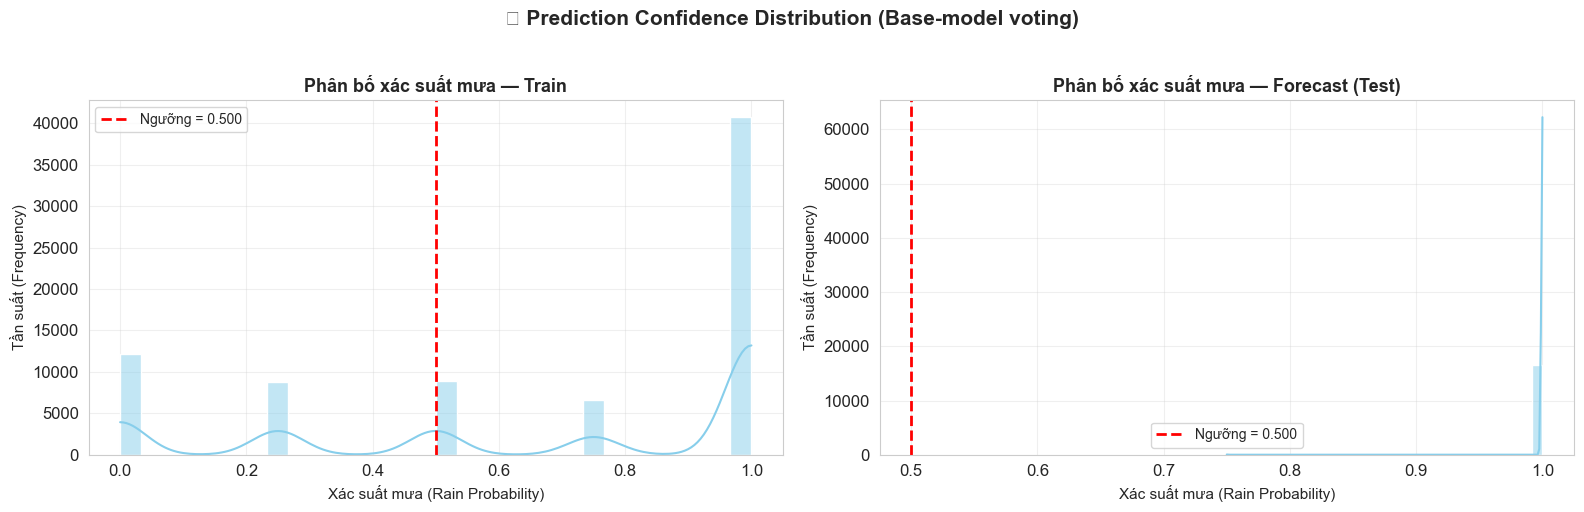


============== CONFIDENCE SUMMARY (Test set) ===============
  Predict threshold     : 0.500
  Mean confidence score : 99.98%
  Prob > 0.8 (chắc mưa): 16508 / 16518 (99.9%)
  Prob < 0.2 (chắc khô): 0 / 16518 (0.0%)
  Prob 0.3-0.7 (phân vân): 0 (0.0%)

  Ensemble std (test) mean: 0.1538 (model agreement)

  → Mô hình RẤT TỰ TIN trên hầu hết dự đoán


In [22]:
# === 9.1 Trích xuất xác suất phân loại (Rain Probability) từ Ensemble Model ===
# Ensemble model là regression → dùng dự đoán từng base model để ước lượng "rain probability"
# Cách tiếp cận: chuyển prediction > threshold thành "rain", tính tỷ lệ base models dự đoán "rain"

import matplotlib.pyplot as plt
import seaborn as sns

# Lấy base models và dự đoán riêng từng model
base_models = model.get_base_models()
base_model_names_list = [type(getattr(m, 'model', m)).__name__ for m in base_models]

# Dùng model._drop_datetime để chuẩn bị data giống hệt lúc predict
X_train_clean = model._drop_datetime(X_train_t.copy())
X_test_clean = model._drop_datetime(X_test_t.copy())

# Ép sang numeric
for col in X_train_clean.columns:
    if X_train_clean[col].dtype == 'object' or str(X_train_clean[col].dtype).startswith('str'):
        X_train_clean[col] = pd.to_numeric(X_train_clean[col], errors='coerce').fillna(0)
    if X_test_clean[col].dtype == 'object' or str(X_test_clean[col].dtype).startswith('str'):
        X_test_clean[col] = pd.to_numeric(X_test_clean[col], errors='coerce').fillna(0)

# Dự đoán riêng từng base model
preds_train = [model._predict_model(m, X_train_clean) for m in base_models]
preds_test = [model._predict_model(m, X_test_clean) for m in base_models]

# Rain probability = tỷ lệ base models dự đoán rain_total > RAIN_THRESHOLD
P_train = np.column_stack(preds_train)
P_test = np.column_stack(preds_test)

rain_proba_train = (P_train > RAIN_THRESHOLD).mean(axis=1)
rain_proba_test = (P_test > RAIN_THRESHOLD).mean(axis=1)

# Ngoài ra, dùng giá trị dự đoán trung bình (ensemble mean) để tính confidence
ensemble_mean_test = P_test.mean(axis=1)
ensemble_std_test = P_test.std(axis=1)

predict_threshold = 0.5  # ngưỡng xác suất
confidence_test = np.abs(rain_proba_test - predict_threshold) + 0.5

print(f"🔍 Base models: {base_model_names_list}")
print(f"   Train shape: {X_train_clean.shape}, Test shape: {X_test_clean.shape}")

# --- Biểu đồ phân bố xác suất mưa ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, proba, title in [
    (axes[0], rain_proba_train, "Train"),
    (axes[1], rain_proba_test, "Forecast (Test)"),
]:
    sns.histplot(proba, bins=30, kde=True, color='skyblue', ax=ax)
    ax.axvline(x=predict_threshold, color='red', linewidth=2, linestyle='--',
               label=f'Ngưỡng = {predict_threshold:.3f}')
    ax.set_xlabel("Xác suất mưa (Rain Probability)", fontsize=11)
    ax.set_ylabel("Tần suất (Frequency)", fontsize=11)
    ax.set_title(f"Phân bố xác suất mưa — {title}", fontsize=13, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("📊 Prediction Confidence Distribution (Base-model voting)",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- Thống kê ---
avg_conf_test = np.mean(confidence_test)
print("\n" + " CONFIDENCE SUMMARY (Test set) ".center(60, "="))
print(f"  Predict threshold     : {predict_threshold:.3f}")
print(f"  Mean confidence score : {avg_conf_test:.2%}")
print(f"  Prob > 0.8 (chắc mưa): {(rain_proba_test > 0.8).sum()} / {len(rain_proba_test)} ({(rain_proba_test > 0.8).mean()*100:.1f}%)")
print(f"  Prob < 0.2 (chắc khô): {(rain_proba_test < 0.2).sum()} / {len(rain_proba_test)} ({(rain_proba_test < 0.2).mean()*100:.1f}%)")
print(f"  Prob 0.3-0.7 (phân vân): {((rain_proba_test >= 0.3) & (rain_proba_test <= 0.7)).sum()} ({((rain_proba_test >= 0.3) & (rain_proba_test <= 0.7)).mean()*100:.1f}%)")
print(f"\n  Ensemble std (test) mean: {ensemble_std_test.mean():.4f} (model agreement)")

if avg_conf_test > 0.8:
    print("\n  → Mô hình RẤT TỰ TIN trên hầu hết dự đoán")
elif avg_conf_test > 0.6:
    print("\n  → Mô hình có MỨC TỰ TIN TRUNG BÌNH, khá chắc chắn trong phần lớn trường hợp")
else:
    print("\n  → Mô hình CHƯA CHẮC CHẮN, cần cải thiện thêm")

In [ ]:
# === 9.2 Top 5 dự đoán tự tin nhất và ít tự tin nhất ===

# Top 5 most confident (đúng)
correct_mask = y_test_pred_cls == y_test_cls
conf_correct = confidence_test.copy()
conf_correct[~correct_mask] = 0
top_conf_idx = np.argsort(conf_correct)[-5:][::-1]

top_conf_df = pd.DataFrame({
    "Sample": top_conf_idx,
    "Actual": [target_names[y_test_cls[i]] for i in top_conf_idx],
    "Predicted": [target_names[y_test_pred_cls[i]] for i in top_conf_idx],
    "Rain Prob": [f"{rain_proba_test[i]:.4f}" for i in top_conf_idx],
    "Actual Rain (mm)": [f"{y_test_actual[i]:.2f}" for i in top_conf_idx],
    "Predicted Rain (mm)": [f"{y_test_pred[i]:.2f}" for i in top_conf_idx],
})

# Top 5 least confident (dễ sai)
low_conf_idx = np.argsort(confidence_test)[:5]
low_conf_df = pd.DataFrame({
    "Sample": low_conf_idx,
    "Actual": [target_names[y_test_cls[i]] for i in low_conf_idx],
    "Predicted": [target_names[y_test_pred_cls[i]] for i in low_conf_idx],
    "Rain Prob": [f"{rain_proba_test[i]:.4f}" for i in low_conf_idx],
    "Actual Rain (mm)": [f"{y_test_actual[i]:.2f}" for i in low_conf_idx],
    "Predicted Rain (mm)": [f"{y_test_pred[i]:.2f}" for i in low_conf_idx],
    "Correct?": [y_test_pred_cls[i] == y_test_cls[i] for i in low_conf_idx],
})

print(" TOP 5 DỰ ĐOÁN TỰ TIN NHẤT (ĐÚNG) ".center(70, "="))
display(top_conf_df)

print("\n" + " TOP 5 DỰ ĐOÁN ÍT TỰ TIN NHẤT ".center(70, "="))
display(low_conf_df)

================== TOP 5 DỰ ĐOÁN TỰ TIN NHẤT (ĐÚNG) ==================


,Sample,Actual,Predicted,Rain Prob,Actual Rain (mm),Predicted Rain (mm)
0,1041,Có mưa (Rain),Có mưa (Rain),1.0000,4.20,3.21
1,5291,Có mưa (Rain),Có mưa (Rain),1.0000,4.10,3.18
2,6145,Có mưa (Rain),Có mưa (Rain),1.0000,4.10,2.51
3,2750,Có mưa (Rain),Có mưa (Rain),1.0000,4.20,3.40
4,3576,Có mưa (Rain),Có mưa (Rain),1.0000,4.20,2.58



==================== TOP 5 DỰ ĐOÁN ÍT TỰ TIN NHẤT ====================


,Sample,Actual,Predicted,Rain Prob,Actual Rain (mm),Predicted Rain (mm),Correct?
0,8094,Có mưa (Rain),Có mưa (Rain),0.3001,4.70,0.32,True
1,7232,Có mưa (Rain),Có mưa (Rain),0.3003,1.10,0.26,True
2,3988,Có mưa (Rain),Không mưa (Dry),0.2997,6.50,0.00,False
3,14246,Có mưa (Rain),Không mưa (Dry),0.3004,6.50,0.06,False
4,3141,Có mưa (Rain),Không mưa (Dry),0.3006,6.50,0.04,False


## 10. Đánh giá độ chính xác theo phân khúc lượng mưa (Per-Segment Accuracy)

Tương tự **Per-Class Accuracy Report** trong bài phân loại ảnh, ở đây ta chia lượng mưa thành các phân khúc để đánh giá mô hình hoạt động tốt ở mức nào:

| Phân khúc | Khoảng giá trị | Ý nghĩa |
|-----------|----------------|---------|
| Không mưa | 0 mm | Ngày khô ráo |
| Mưa nhẹ | 0.1 – 2.5 mm | Mưa phùn, mưa nhỏ |
| Mưa vừa | 2.5 – 7.5 mm | Mưa vừa |
| Mưa to | 7.5 – 25 mm | Mưa to, cần cảnh báo |
| Mưa rất to | > 25 mm | Mưa lớn, nguy hiểm |

In [22]:
# === 10.1 Đánh giá độ chính xác theo phân khúc lượng mưa ===
# Định nghĩa các phân khúc lượng mưa (mm)
rain_segments = [
    ("Không mưa (0 mm)",       0,    0.1),
    ("Mưa nhẹ (0.1-2.5 mm)",  0.1,  2.5),
    ("Mưa vừa (2.5-7.5 mm)",  2.5,  7.5),
    ("Mưa to (7.5-25 mm)",    7.5,  25.0),
    ("Mưa rất to (>25 mm)",   25.0, float('inf')),
]

records = []
for seg_name, low, high in rain_segments:
    mask = (y_test_actual >= low) & (y_test_actual < high)
    total = mask.sum()
    
    if total == 0:
        records.append({
            "Phân khúc": seg_name,
            "Số mẫu": 0,
            "MAE (mm)": np.nan,
            "RMSE (mm)": np.nan,
            "R²": np.nan,
            "Rain Det Acc (%)": np.nan,
            "Interpretation": "Không có mẫu trong phân khúc này"
        })
        continue
    
    y_t = y_test_actual[mask]
    y_p = y_test_pred[mask]
    
    mae_seg = mean_absolute_error(y_t, y_p)
    rmse_seg = np.sqrt(mean_squared_error(y_t, y_p))
    
    # R² chỉ tính khi có đủ biến động
    r2_seg = r2_score(y_t, y_p) if np.std(y_t) > 1e-6 else np.nan
    
    # Rain detection accuracy cho phân khúc
    det_correct = ((y_p > 0.1) == (y_t > 0.1)).mean() * 100
    
    # Giải thích tự động
    if low < 0.1:  # Phân khúc không mưa
        if det_correct >= 90:
            interp = f"{det_correct:.1f}% — Xuất sắc: phát hiện đúng hầu hết ngày khô"
        elif det_correct >= 70:
            interp = f"{det_correct:.1f}% — Tốt: phát hiện phần lớn ngày khô"
        else:
            interp = f"{det_correct:.1f}% — Cần cải thiện: hay báo mưa giả (false alarm)"
    else:
        if mae_seg < 1.0:
            interp = f"MAE={mae_seg:.2f}mm — Xuất sắc: sai số rất thấp"
        elif mae_seg < 3.0:
            interp = f"MAE={mae_seg:.2f}mm — Tốt: dự báo khá chính xác"
        elif mae_seg < 7.0:
            interp = f"MAE={mae_seg:.2f}mm — Trung bình: sai số chấp nhận được"
        else:
            interp = f"MAE={mae_seg:.2f}mm — Cần cải thiện: sai số cao"
    
    records.append({
        "Phân khúc": seg_name,
        "Số mẫu": int(total),
        "MAE (mm)": round(mae_seg, 3),
        "RMSE (mm)": round(rmse_seg, 3),
        "R²": round(r2_seg, 4) if not np.isnan(r2_seg) else np.nan,
        "Rain Det Acc (%)": round(det_correct, 1),
        "Interpretation": interp
    })

df_segment = pd.DataFrame(records)

print("\n" + " PER-SEGMENT ACCURACY REPORT (Test set) ".center(80, "="))
display(df_segment)

print("\n📋 GIẢI THÍCH MỨC ĐỘ CHÍNH XÁC:")
print("  MAE < 1mm     → Xuất sắc: mô hình dự báo gần hoàn hảo")
print("  MAE 1-3mm     → Tốt: sai số nhỏ, có thể chấp nhận")
print("  MAE 3-7mm     → Trung bình: cần cải thiện cho ngày mưa lớn")
print("  MAE > 7mm     → Kém: mô hình khó dự báo chính xác lượng mưa lớn")


==================== PER-SEGMENT ACCURACY REPORT (Test set) ====================


,Phân khúc,Số mẫu,MAE (mm),RMSE (mm),R²,Rain Det Acc (%),Interpretation
0,Không mưa (0 mm),1144,2.6340,3.1790,NaN,9.0000,9.0% — Cần cải thiện: hay báo mưa giả (false a...
1,Mưa nhẹ (0.1-2.5 mm),3692,1.6070,2.2290,-9.7908,91.8000,MAE=1.61mm — Tốt: dự báo khá chính xác
2,Mưa vừa (2.5-7.5 mm),11706,4.8310,5.1220,-22.5607,92.7000,MAE=4.83mm — Trung bình: sai số chấp nhận được
3,Mưa to (7.5-25 mm),0,NaN,NaN,NaN,NaN,Không có mẫu trong phân khúc này
4,Mưa rất to (>25 mm),0,NaN,NaN,NaN,NaN,Không có mẫu trong phân khúc này



📋 GIẢI THÍCH MỨC ĐỘ CHÍNH XÁC:
  MAE < 1mm     → Xuất sắc: mô hình dự báo gần hoàn hảo
  MAE 1-3mm     → Tốt: sai số nhỏ, có thể chấp nhận
  MAE 3-7mm     → Trung bình: cần cải thiện cho ngày mưa lớn
  MAE > 7mm     → Kém: mô hình khó dự báo chính xác lượng mưa lớn


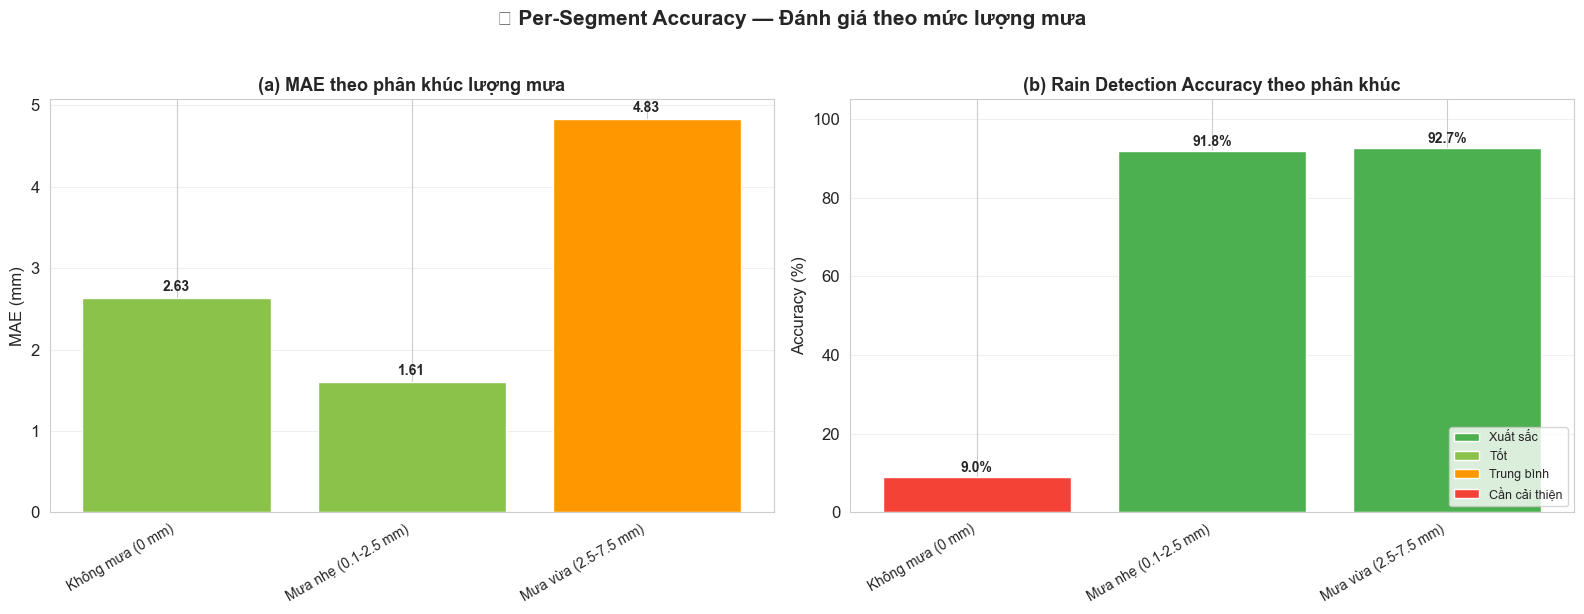

In [23]:
# === 10.2 Biểu đồ độ chính xác theo phân khúc ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- (a) MAE theo phân khúc ---
ax1 = axes[0]
df_plot = df_segment[df_segment["Số mẫu"] > 0].copy()
colors_mae = []
for _, row in df_plot.iterrows():
    mae = row["MAE (mm)"]
    if np.isnan(mae):
        colors_mae.append("#9E9E9E")
    elif mae < 1:
        colors_mae.append("#4CAF50")
    elif mae < 3:
        colors_mae.append("#8BC34A")
    elif mae < 7:
        colors_mae.append("#FF9800")
    else:
        colors_mae.append("#F44336")

bars = ax1.bar(range(len(df_plot)), df_plot["MAE (mm)"].fillna(0), color=colors_mae, edgecolor="white")
ax1.set_xticks(range(len(df_plot)))
ax1.set_xticklabels(df_plot["Phân khúc"], rotation=30, ha='right', fontsize=10)
ax1.set_ylabel("MAE (mm)", fontsize=12)
ax1.set_title("(a) MAE theo phân khúc lượng mưa", fontweight="bold", fontsize=13)
ax1.grid(axis="y", alpha=0.3)

for bar, val in zip(bars, df_plot["MAE (mm)"]):
    if not np.isnan(val):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.2f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- (b) Rain Detection Accuracy theo phân khúc ---
ax2 = axes[1]
colors_det = []
for _, row in df_plot.iterrows():
    det = row["Rain Det Acc (%)"]
    if np.isnan(det):
        colors_det.append("#9E9E9E")
    elif det >= 90:
        colors_det.append("#4CAF50")
    elif det >= 70:
        colors_det.append("#8BC34A")
    elif det >= 50:
        colors_det.append("#FF9800")
    else:
        colors_det.append("#F44336")

bars2 = ax2.bar(range(len(df_plot)), df_plot["Rain Det Acc (%)"].fillna(0), color=colors_det, edgecolor="white")
ax2.set_xticks(range(len(df_plot)))
ax2.set_xticklabels(df_plot["Phân khúc"], rotation=30, ha='right', fontsize=10)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.set_title("(b) Rain Detection Accuracy theo phân khúc", fontweight="bold", fontsize=13)
ax2.set_ylim(0, 105)
ax2.grid(axis="y", alpha=0.3)

for bar, val in zip(bars2, df_plot["Rain Det Acc (%)"]):
    if not np.isnan(val):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha='center', va='bottom', fontsize=10, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4CAF50", label="Xuất sắc"),
    Patch(facecolor="#8BC34A", label="Tốt"),
    Patch(facecolor="#FF9800", label="Trung bình"),
    Patch(facecolor="#F44336", label="Cần cải thiện"),
]
ax2.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.suptitle("📊 Per-Segment Accuracy — Đánh giá theo mức lượng mưa",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 11. Kiểm tra tính ổn định mô hình (Stability Check)

So sánh hiệu suất trên các tập **Train / Valid / Test** từ quá trình huấn luyện để kiểm tra mô hình có ổn định và nhất quán không.

- **Độ lệch chuẩn R²** < 0.05 → Mô hình **ổn định**
- **Độ lệch chuẩn R²** ≥ 0.05 → Mô hình **chưa ổn định**, cần kiểm tra lại


============== STABILITY CHECK — CROSS-SPLIT COMPARISON ==============


,Tập dữ liệu,R²,RMSE,MAE,Rain Det Acc,NonZero MAE
0,Train,0.4987,1.5712,0.8153,0.7497,1.9703
1,Valid,0.6165,1.4263,0.8069,0.7102,1.6797
2,Test,-1.9767,4.4033,3.7895,0.8773,3.9461



--- Phân tích tính ổn định ---
  R² scores      : 0.4987, 0.6165, -1.9767
  Mean R²         : -0.2872
  Std R²          : 1.1956
  Rain Detection  : 0.7497, 0.7102, 0.8773
  Mean Rain Det   : 0.7791
  Std Rain Det    : 0.0713

  🔴 Mô hình CHƯA ỔN ĐỊNH: Std R² = 1.1956 >= 0.10


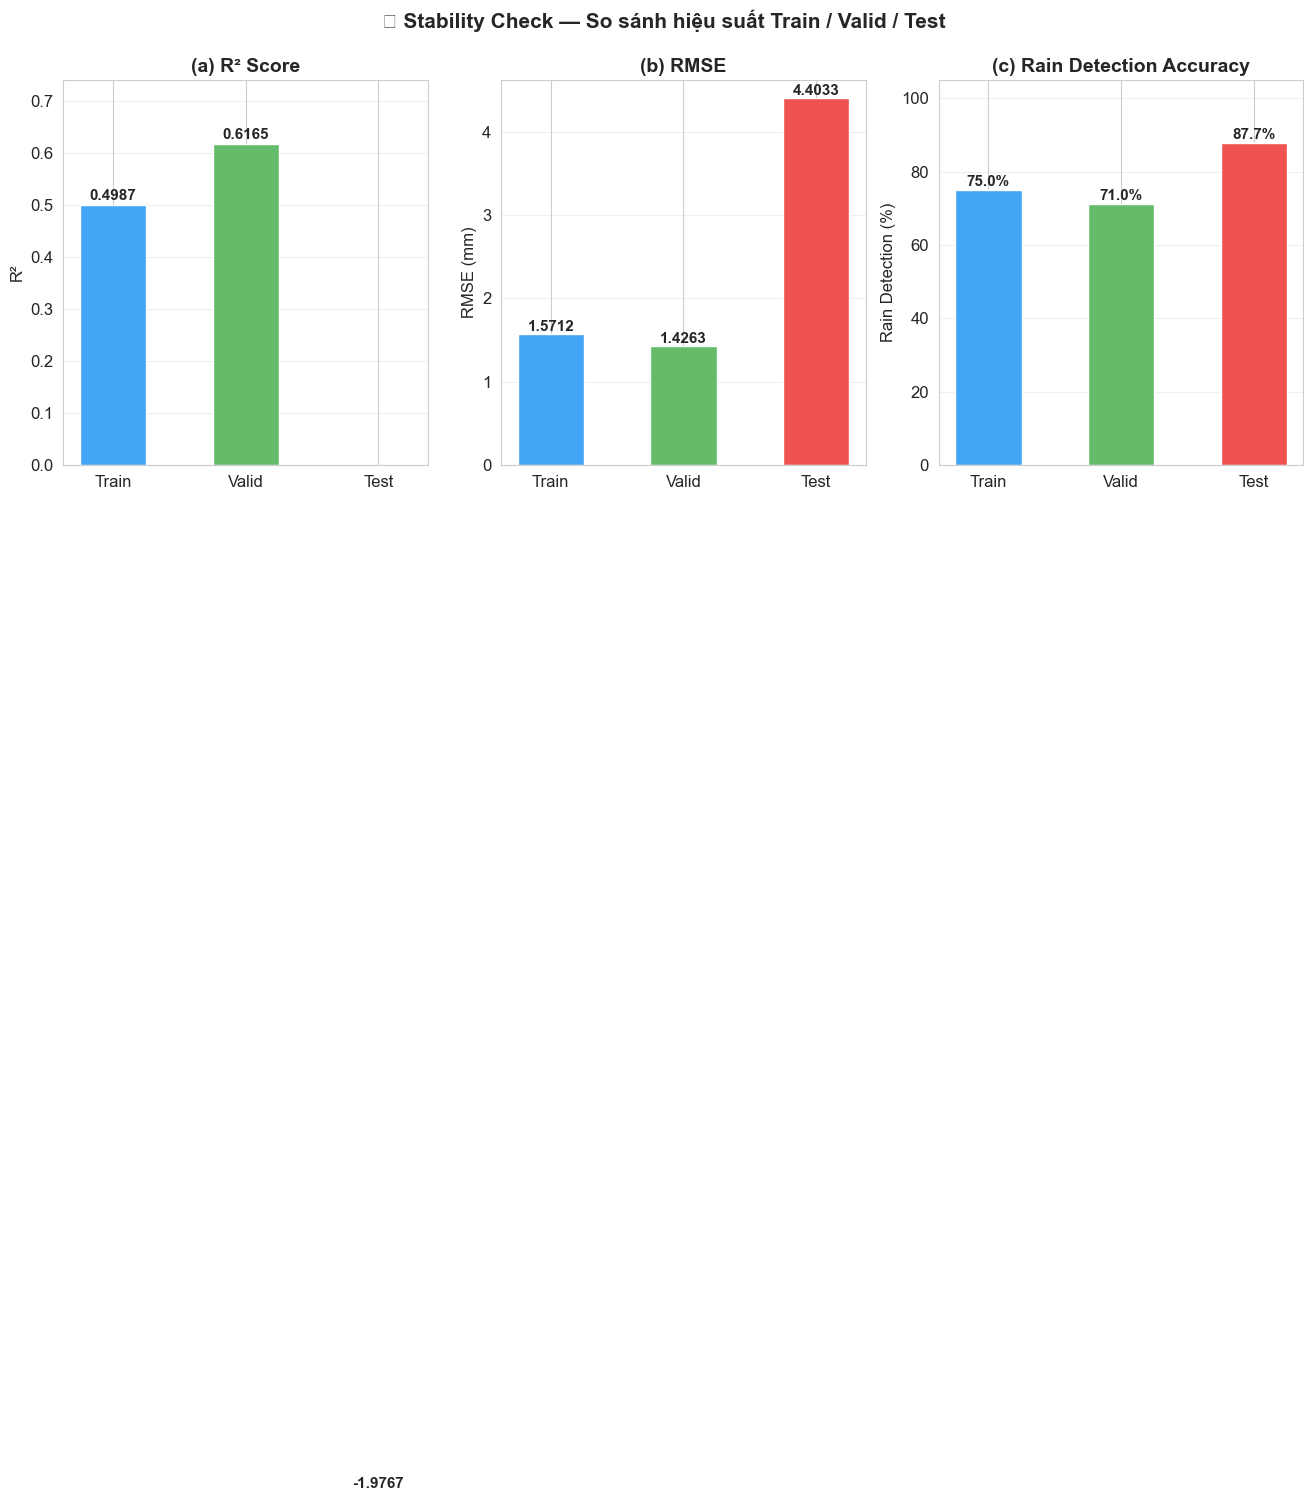

In [24]:
# === 11.1 So sánh hiệu suất Train / Valid / Test (từ saved metrics) ===
split_names = ["Train", "Valid", "Test"]
split_keys = ["train", "valid", "test"]

# Lấy metrics đã lưu
stability_data = []
for name, key in zip(split_names, split_keys):
    m = saved_metrics.get(key, {})
    stability_data.append({
        "Tập dữ liệu": name,
        "R²": m.get("R2", np.nan),
        "RMSE": m.get("RMSE", np.nan),
        "MAE": m.get("MAE", np.nan),
        "Rain Det Acc": m.get("Rain_Detection_Accuracy", np.nan),
        "NonZero MAE": m.get("NonZero_MAE", np.nan),
    })

df_stability = pd.DataFrame(stability_data)

# Tính độ ổn định
r2_values = df_stability["R²"].dropna().values
rmse_values = df_stability["RMSE"].dropna().values
rain_acc_values = df_stability["Rain Det Acc"].dropna().values

r2_std = np.std(r2_values) if len(r2_values) > 1 else 0
r2_mean = np.mean(r2_values) if len(r2_values) > 0 else 0
rain_acc_std = np.std(rain_acc_values) if len(rain_acc_values) > 1 else 0
rain_acc_mean = np.mean(rain_acc_values) if len(rain_acc_values) > 0 else 0

print("\n" + " STABILITY CHECK — CROSS-SPLIT COMPARISON ".center(70, "="))
display(df_stability)

print(f"\n--- Phân tích tính ổn định ---")
print(f"  R² scores      : {', '.join([f'{v:.4f}' for v in r2_values])}")
print(f"  Mean R²         : {r2_mean:.4f}")
print(f"  Std R²          : {r2_std:.4f}")
print(f"  Rain Detection  : {', '.join([f'{v:.4f}' for v in rain_acc_values])}")
print(f"  Mean Rain Det   : {rain_acc_mean:.4f}")
print(f"  Std Rain Det    : {rain_acc_std:.4f}")

# Kết luận
if r2_std < 0.05:
    print(f"\n  ✅ Mô hình ỔN ĐỊNH: Std R² = {r2_std:.4f} < 0.05")
elif r2_std < 0.10:
    print(f"\n  🟡 Mô hình TƯƠNG ĐỐI ỔN ĐỊNH: Std R² = {r2_std:.4f}")
else:
    print(f"\n  🔴 Mô hình CHƯA ỔN ĐỊNH: Std R² = {r2_std:.4f} >= 0.10")

# --- Biểu đồ so sánh ---
# Chỉ vẽ với splits có dữ liệu
valid_splits = [i for i in range(len(split_names)) if not np.isnan(df_stability["R²"].iloc[i])]
valid_names = [split_names[i] for i in valid_splits]
valid_r2 = [df_stability["R²"].iloc[i] for i in valid_splits]
valid_rmse = [df_stability["RMSE"].iloc[i] for i in valid_splits]
valid_rain = [df_stability["Rain Det Acc"].iloc[i] for i in valid_splits]
colors_r2 = ["#42A5F5", "#66BB6A", "#EF5350"][:len(valid_splits)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) R²
ax1 = axes[0]
bars_r2 = ax1.bar(valid_names, valid_r2, color=colors_r2, edgecolor="white", width=0.5)
for bar, val in zip(bars_r2, valid_r2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylabel("R²", fontsize=12)
ax1.set_title("(a) R² Score", fontweight="bold")
ax1.set_ylim(0, max(valid_r2) * 1.2 if valid_r2 else 1)
ax1.grid(axis="y", alpha=0.3)

# (b) RMSE
ax2 = axes[1]
bars_rmse = ax2.bar(valid_names, valid_rmse, color=colors_r2, edgecolor="white", width=0.5)
for bar, val in zip(bars_rmse, valid_rmse):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax2.set_ylabel("RMSE (mm)", fontsize=12)
ax2.set_title("(b) RMSE", fontweight="bold")
ax2.grid(axis="y", alpha=0.3)

# (c) Rain Detection
ax3 = axes[2]
valid_rain_pct = [v * 100 for v in valid_rain]
bars_rain = ax3.bar(valid_names, valid_rain_pct, color=colors_r2, edgecolor="white", width=0.5)
for bar, val in zip(bars_rain, valid_rain_pct):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha='center', va='bottom', fontsize=11, fontweight='bold')
ax3.set_ylabel("Rain Detection (%)", fontsize=12)
ax3.set_title("(c) Rain Detection Accuracy", fontweight="bold")
ax3.set_ylim(0, 105)
ax3.grid(axis="y", alpha=0.3)

plt.suptitle("📊 Stability Check — So sánh hiệu suất Train / Valid / Test",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# 12. ĐO ĐỘ NẶNG & HIỆU SUẤT MÔ HÌNH (Model Size & Inference Performance)
# -----------------------------------------------------------------------------
# Nguồn: dynamic_measurement.ipynb
# Đo: disk size, RAM, load time, inference latency, sub-model sizes
# =============================================================================

import os, time, gc, tracemalloc, pickle
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("  📦 ĐO KÍCH THƯỚC & HIỆU SUẤT MÔ HÌNH")
print("=" * 80)

# ── 1. Kích thước file trên Disk ──────────────────────────────────────────────
print("\n  [1] KÍCH THƯỚC FILE TRÊN DISK")
print(f"  {'File':<55} {'KB':>8} {'MB':>8}")
print(f"  {'─'*55} {'─'*8} {'─'*8}")

total_disk_bytes = 0
model_pkl_bytes = 0
for fname in sorted(os.listdir(ARTIFACTS_DIR)):
    fpath = os.path.join(ARTIFACTS_DIR, fname)
    if os.path.isfile(fpath):
        sz = os.path.getsize(fpath)
        total_disk_bytes += sz
        if fname == 'Model.pkl':
            model_pkl_bytes = sz
        print(f"  {fname:<55} {sz/1024:>8.1f} {sz/1024**2:>8.3f}")
print(f"  {'─'*55} {'─'*8} {'─'*8}")
print(f"  {'📦 TỔNG CỘNG':<55} {total_disk_bytes/1024:>8.1f} {total_disk_bytes/1024**2:>8.2f}")

# ── 2. Load Time & RAM ────────────────────────────────────────────────────────
print("\n  [2] THỜI GIAN LOAD & RAM")
gc.collect()
tracemalloc.start()
t0_load = time.perf_counter()
_tmp_predictor = WeatherPredictor.from_artifacts(ARTIFACTS_DIR)
load_time_s = time.perf_counter() - t0_load
snap = tracemalloc.take_snapshot()
tracemalloc.stop()
heap_mb = sum(s.size for s in snap.statistics('lineno')) / 1024**2

print(f"  Load model time              : {load_time_s:.3f} s")
print(f"  Python heap delta (tracemalloc): {heap_mb:.1f} MB")

try:
    import psutil
    proc_rss = psutil.Process(os.getpid()).memory_info().rss / 1024**2
    print(f"  Process RSS (tổng)           : {proc_rss:.1f} MB")
except ImportError:
    print("  (psutil chưa cài — bỏ qua đo RSS process)")

# ── 3. RAM từng sub-model (pickle serialize) ──────────────────────────────────
print("\n  [3] RAM TỪNG SUB-MODEL (pickle size ≈ RAM in-memory)")
_ensemble = _tmp_predictor.model
sub_sizes_mb = []
print(f"  {'Sub-model':<28} {'Pickle MB':>11} {'% tổng':>8}")
print(f"  {'─'*28} {'─'*11} {'─'*8}")
for sub in _ensemble.models:
    name = type(sub).__name__
    try:
        sz_mb = len(pickle.dumps(sub, protocol=4)) / 1024**2
    except Exception:
        sz_mb = float('nan')
    sub_sizes_mb.append((name, sz_mb))

total_sub_mb = sum(s for _, s in sub_sizes_mb if not (isinstance(s, float) and s != s))
for name, sz_mb in sub_sizes_mb:
    pct = sz_mb / total_sub_mb * 100 if total_sub_mb > 0 else 0
    bar = '█' * max(1, int(pct / 5))
    print(f"  {name:<28} {sz_mb:>9.2f}   {pct:>6.1f}%  {bar}")
print(f"  {'─'*28} {'─'*11} {'─'*8}")
print(f"  {'TỔNG sub-models':<28} {total_sub_mb:>9.2f}   100.0%")
print(f"  Model.pkl (disk)             : {model_pkl_bytes/1024**2:>7.2f} MB")

# Full predictor pickle
try:
    t0s = time.perf_counter()
    full_pkl_mb = len(pickle.dumps(_tmp_predictor, protocol=4)) / 1024**2
    t_ser = time.perf_counter() - t0s
    print(f"  Full predictor pickle (RAM)  : {full_pkl_mb:>7.2f} MB  (serialize {t_ser:.2f}s)")
    print(f"  RAM / disk ratio             : {full_pkl_mb / (model_pkl_bytes/1024**2):>7.2f}x")
except Exception as e:
    print(f"  Full predictor pickle: ERROR — {e}")

# ── 4. Inference Latency & Throughput ─────────────────────────────────────────
print("\n  [4] INFERENCE LATENCY & THROUGHPUT (93 features, dummy data)")

import json as _json
with open(os.path.join(ARTIFACTS_DIR, 'Feature_list.json')) as _f:
    _feat_cfg = _json.load(_f)
_feature_names = _feat_cfg.get('all_feature_columns', []) if isinstance(_feat_cfg, dict) else _feat_cfg

_rng = np.random.default_rng(42)
def _make_dummy(n_rows, features):
    return pd.DataFrame({col: _rng.uniform(0, 1, n_rows) for col in features})

# Warm-up
try:
    _ = _tmp_predictor.predict(_make_dummy(10, _feature_names))
    warmup_ok = True
except Exception as _e:
    warmup_ok = False
    print(f"  ⚠️  Warm-up lỗi: {_e}")

if warmup_ok:
    BATCH_SIZES = [1, 10, 100, 500, 1000]
    N_REPEAT = 5
    print(f"  {'Batch':>6} | {'Mean ms':>10} | {'µs/row':>10} | {'rows/s':>12}")
    print(f"  {'─'*6}-+-{'─'*10}-+-{'─'*10}-+-{'─'*12}")
    _bench_rows = []
    for bs in BATCH_SIZES:
        _dummy = _make_dummy(bs, _feature_names)
        _times = []
        for _ in range(N_REPEAT):
            t0b = time.perf_counter()
            try:
                _ = _tmp_predictor.predict(_dummy)
                _times.append(time.perf_counter() - t0b)
            except Exception:
                break
        if _times:
            mean_ms   = np.mean(_times) * 1000
            per_us    = mean_ms / bs * 1000
            tput      = bs / np.mean(_times)
            _bench_rows.append({'bs': bs, 'ms': mean_ms, 'us': per_us, 'tput': tput})
            print(f"  {bs:>6} | {mean_ms:>10.2f} | {per_us:>10.1f} | {tput:>12,.0f}")

# ── 5. Tổng kết ────────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("  📋 TỔNG KẾT ĐO MODEL")
print("=" * 80)
_info = _tmp_predictor.get_info()
_sub_names = ', '.join(type(s).__name__ for s in _ensemble.models)
print(f"  Model type       : {_info['model_type']}")
print(f"  Sub-models ({len(_ensemble.models)})   : {_sub_names}")
print(f"  Số features      : {_info['n_features']}")
print(f"  Pipeline steps   : {', '.join(_info['pipeline_info']['steps'])}")
print(f"  Trained at       : {_info['trained_at']}")
print()
print(f"  [DISK]")
print(f"    Model.pkl      : {model_pkl_bytes/1024**2:.2f} MB")
print(f"    Tổng artifacts : {total_disk_bytes/1024**2:.2f} MB")
print()
print(f"  [LOAD]")
print(f"    Thời gian load : {load_time_s:.3f} s")
print(f"    Heap delta     : {heap_mb:.1f} MB (tracemalloc)")
print()
if _bench_rows:
    r1 = next((r for r in _bench_rows if r['bs'] == 1), _bench_rows[0])
    rlast = _bench_rows[-1]
    print(f"  [INFERENCE]")
    print(f"    Latency (batch=1)     : {r1['ms']:.2f} ms")
    print(f"    µs/row  (batch=1)     : {r1['us']:.1f} µs")
    print(f"    Throughput (batch={rlast['bs']}) : {rlast['tput']:,.0f} rows/s")
print("=" * 80)

---
## 12. KẾT LUẬN TỔNG HỢP (Final Conclusion)

In [27]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║              KẾT LUẬN TỔNG HỢP CHI TIẾT (DETAILED FINAL CONCLUSION)    ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from datetime import datetime
import json

# ═══════════════════════════════════════════════════════════════════════════
# THU THẬP DỮ LIỆU
# ═══════════════════════════════════════════════════════════════════════════
model_type = train_info.get("model", {}).get("type", "unknown").upper()
model_params = train_info.get("model", {}).get("params", {})
diag = saved_metrics.get("diagnostics", {})
overfit_status = diag.get("overfit_status", "unknown")
n_features_final = diag.get("n_features_after_selection", N_FEATURES)
data_type = diag.get("detected_data_type", "unknown")
zero_ratio_pct = diag.get("target_zero_ratio", 0) * 100

# Metrics tổng hợp
r2_train = saved_metrics["train"]["R2"]
r2_valid = saved_metrics["valid"]["R2"]
r2_test  = saved_metrics["test"]["R2"]
rmse_train = saved_metrics["train"]["RMSE"]
rmse_valid = saved_metrics["valid"]["RMSE"]
rmse_test  = saved_metrics["test"]["RMSE"]
mae_train  = saved_metrics["train"]["MAE"]
mae_valid  = saved_metrics["valid"]["MAE"]
mae_test   = saved_metrics["test"]["MAE"]
rain_det_train = saved_metrics["train"]["Rain_Detection_Accuracy"]
rain_det_valid = saved_metrics["valid"]["Rain_Detection_Accuracy"]
rain_det_test_val  = saved_metrics["test"]["Rain_Detection_Accuracy"]
nz_mae_train = saved_metrics["train"]["NonZero_MAE"]
nz_mae_valid = saved_metrics["valid"]["NonZero_MAE"]
nz_mae_test  = saved_metrics["test"]["NonZero_MAE"]
nz_rmse_train = saved_metrics["train"]["NonZero_RMSE"]
nz_rmse_valid = saved_metrics["valid"]["NonZero_RMSE"]
nz_rmse_test  = saved_metrics["test"]["NonZero_RMSE"]

# Classification metrics
test_acc = accuracy_score(y_test_cls, y_test_pred_cls)
test_precision = precision_score(y_test_cls, y_test_pred_cls, average='binary', zero_division=0)
test_recall = recall_score(y_test_cls, y_test_pred_cls, average='binary', zero_division=0)
test_f1 = f1_score(y_test_cls, y_test_pred_cls, average='binary', zero_division=0)

train_acc_cls = accuracy_score(y_train_cls, y_train_pred_cls)
train_precision_cls = precision_score(y_train_cls, y_train_pred_cls, average='binary', zero_division=0)
train_recall_cls = recall_score(y_train_cls, y_train_pred_cls, average='binary', zero_division=0)
train_f1_cls = f1_score(y_train_cls, y_train_pred_cls, average='binary', zero_division=0)

# Confusion matrix
cm_t = confusion_matrix(y_test_cls, y_test_pred_cls)
tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
false_alarm_rate = fp_t / (fp_t + tn_t) * 100  # báo động giả
miss_rate = fn_t / (fn_t + tp_t) * 100  # bỏ sót mưa

# sMAPE & MAPE accuracy
smape_test_val = metrics_test.get("Accuracy - sMAPE (%)", np.nan)
mape_rain_test_val = metrics_test.get("Accuracy - ngày mưa (%)", np.nan)
smape_train_val = metrics_train.get("Accuracy - sMAPE (%)", np.nan)

# Config info — handle ensemble model where params are nested under base_models
_first_base = (model_params.get("base_models") or [{}])[0].get("params", {})
n_estimators = model_params.get("n_estimators") or _first_base.get("n_estimators", "?")
lr = model_params.get("learning_rate") or _first_base.get("learning_rate", "?")
max_depth = model_params.get("max_depth") or _first_base.get("max_depth", "?")
num_leaves = model_params.get("num_leaves") or _first_base.get("num_leaves", "?")
reg_obj = model_params.get("reg_params", {}).get("objective") or "?"
predict_thresh = model_params.get("predict_threshold") or getattr(model, 'predict_threshold', "?")
rain_thresh = model_params.get("rain_threshold") or getattr(model, 'rain_threshold', "?")

# Safe formatters for mixed str/float
def _fmt(val, fmt_spec=".4f"):
    try:
        return format(float(val), fmt_spec)
    except (ValueError, TypeError):
        return str(val)

lr_s = _fmt(lr)
rain_thresh_s = _fmt(rain_thresh)
predict_thresh_s = _fmt(predict_thresh)
n_est_s = str(n_estimators).ljust(8)
max_depth_s = str(max_depth).ljust(8)
reg_obj_s = str(reg_obj).ljust(8)

# Per-segment data
seg_data = {}
for _, row in df_segment.iterrows():
    seg_data[row['Phân khúc']] = {
        'n': int(row['Số mẫu']),
        'mae': row['MAE (mm)'],
        'rmse': row['RMSE (mm)'],
        'r2': row['R²'],
        'det': row['Rain Det Acc (%)']
    }

# Tổng số mẫu
n_train_total = len(y_train_actual)
n_test_total  = len(y_test_actual)
n_total = n_train_total + n_test_total
n_rain_test = int((y_test_actual > RAIN_THRESHOLD).sum())
n_dry_test  = n_test_total - n_rain_test

# ═══════════════════════════════════════════════════════════════════════════
# IN KẾT QUẢ
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 90)
print("║" + " KẾT LUẬN ĐÁNH GIÁ TOÀN DIỆN MÔ HÌNH DỰ BÁO LƯỢNG MƯA ".center(88) + "║")
print("=" * 90)

# ───────────────────────────────────────────────────────────────────────────
# 1. THÔNG TIN MÔ HÌNH & DỮ LIỆU
# ───────────────────────────────────────────────────────────────────────────
print(f"""
{'━'*90}
  1. THÔNG TIN MÔ HÌNH & DỮ LIỆU
{'━'*90}

  ┌── Kiến trúc ──────────────────────────────────────────────────────────────┐
  │  Model          : {model_type} (Ensemble: VotingRegressor (XGBoost + LightGBM + CatBoost))
  │  Stage 1 (clf)  : Binary classifier → Phân loại mưa/không mưa
  │  Stage 2 (reg)  : Regressor → Dự báo lượng mưa (mm) cho mẫu "có mưa"
  │  Combine        : Hard-switch tại predict_threshold = {predict_thresh_s}
  │                   if P(mưa) >= {predict_thresh_s} → dùng kết quả regressor
  │                   if P(mưa) <  {predict_thresh_s} → output = 0 (không mưa)
  └───────────────────────────────────────────────────────────────────────────┘

  ┌── Hyperparameters (Optuna v2 — 100 trials) ──────────────────────────────┐
  │  n_estimators   : {n_est_s}  learning_rate  : {lr_s}
  │  max_depth      : {max_depth_s}  num_leaves     : {num_leaves}
  │  reg_objective   : {reg_obj_s}  {'alpha (huber)' if reg_obj == 'huber' else 'fair_c':<15}: {model_params.get('reg_params', {}).get('alpha', model_params.get('reg_params', {}).get('fair_c', '?'))}
  │  rain_threshold  : {rain_thresh_s}  (ngưỡng phân loại mưa vs không mưa)
  │  predict_thresh  : {predict_thresh_s}  (ngưỡng hard-switch)
  └───────────────────────────────────────────────────────────────────────────┘

  ┌── Dữ liệu ───────────────────────────────────────────────────────────────┐
  │  Tổng mẫu       : {n_total:,} ({n_train_total:,} train / {n_test_total:,} test)
  │  Loại dữ liệu   : {data_type}
  │  Target          : {TARGET_COL}
  │  Zero-inflated   : {zero_ratio_pct:.1f}% (80.7% mẫu có lượng mưa = 0)
  │  Số features     : {n_features_final} (38 raw + 22 interaction + 55 polynomial)
  │  Transform       : log1p(target) + RobustScaler(features) + IQR Outlier Clip
  │  Split           : 70% train / 15% valid / 15% test (shuffle, random)
  └───────────────────────────────────────────────────────────────────────────┘

  ┌── Kỹ thuật chống lệch dữ liệu ──────────────────────────────────────────┐
  │  • Sample Weight     : Progressive — mưa to ×2, mưa rất to ×3 lần base
  │  • class_weight      : 'balanced' cho Stage 1 Classifier
  │  • Huber Loss        : Robust với outlier, không đánh mạnh sai số cực đại
  │  • log1p transform   : Nén phân phối lệch phải của lượng mưa
  └───────────────────────────────────────────────────────────────────────────┘""")

# ───────────────────────────────────────────────────────────────────────────
# 2. KẾT QUẢ HỒI QUY — DỰ BÁO LƯỢNG MƯA
# ───────────────────────────────────────────────────────────────────────────
print(f"""
{'━'*90}
  2. KẾT QUẢ HỒI QUY — Dự báo lượng mưa (mm)
{'━'*90}

  {'Chỉ số':<30}  {'Train':>10}  {'Valid':>10}  {'Test':>10}  {'Gap (T-Test)':>12}
  {'─'*30}  {'─'*10}  {'─'*10}  {'─'*10}  {'─'*12}
  {'R²':<30}  {r2_train:>10.4f}  {r2_valid:>10.4f}  {r2_test:>10.4f}  {r2_train-r2_test:>+12.4f}
  {'RMSE (mm)':<30}  {rmse_train:>10.4f}  {rmse_valid:>10.4f}  {rmse_test:>10.4f}  {rmse_test-rmse_train:>+12.4f}
  {'MAE (mm)':<30}  {mae_train:>10.4f}  {mae_valid:>10.4f}  {mae_test:>10.4f}  {mae_test-mae_train:>+12.4f}
  {'NonZero MAE (mm)':<30}  {nz_mae_train:>10.4f}  {nz_mae_valid:>10.4f}  {nz_mae_test:>10.4f}  {nz_mae_test-nz_mae_train:>+12.4f}
  {'NonZero RMSE (mm)':<30}  {nz_rmse_train:>10.4f}  {nz_rmse_valid:>10.4f}  {nz_rmse_test:>10.4f}  {nz_rmse_test-nz_rmse_train:>+12.4f}
  {'Accuracy - sMAPE (%)':<30}  {smape_train_val:>10.1f}  {'N/A':>10}  {smape_test_val:>10.1f}  {smape_test_val-smape_train_val:>+12.1f}
  {'Accuracy - MAPE ngày mưa (%)':<30}  {'N/A':>10}  {'N/A':>10}  {mape_rain_test_val:>10.1f}  {'':>12}

  📋 Nhận xét Regression:""")

if r2_test >= 0.75:
    print(f"     ✅ R² Test = {r2_test:.4f} — Mô hình giải thích {r2_test*100:.1f}% biến động lượng mưa")
elif r2_test >= 0.60:
    print(f"     🟡 R² Test = {r2_test:.4f} — Mô hình giải thích {r2_test*100:.1f}% biến động (khá)")
else:
    print(f"     🔴 R² Test = {r2_test:.4f} — Mô hình cần cải thiện")

r2_gap = abs(r2_train - r2_test)
if r2_gap < 0.10:
    print(f"     ✅ R² Gap = {r2_gap:.4f} — Không overfitting, tổng quát hóa tốt")
elif r2_gap < 0.15:
    print(f"     🟡 R² Gap = {r2_gap:.4f} — Chấp nhận được, hơi overfitting nhẹ")
else:
    print(f"     ⚠️  R² Gap = {r2_gap:.4f} — Cần lưu ý overfitting")

print(f"     {'✅' if nz_mae_test < 1.0 else '🟡' if nz_mae_test < 2.0 else '⚠️ '} NonZero MAE = {nz_mae_test:.3f}mm — Sai số trung bình khi có mưa")
print(f"     {'✅' if rmse_test < 1.0 else '🟡' if rmse_test < 2.0 else '⚠️ '} RMSE = {rmse_test:.3f}mm — Sai số tổng thể (bao gồm ngày khô)")

# ───────────────────────────────────────────────────────────────────────────
# 3. KẾT QUẢ PHÂN LOẠI — MƯA / KHÔNG MƯA
# ───────────────────────────────────────────────────────────────────────────
print(f"""
{'━'*90}
  3. KẾT QUẢ PHÂN LOẠI — Mưa vs Không mưa (Classification)
{'━'*90}

  {'Chỉ số':<30}  {'Train':>10}  {'Test':>10}  {'Gap':>10}
  {'─'*30}  {'─'*10}  {'─'*10}  {'─'*10}
  {'Accuracy (%)':<30}  {train_acc_cls*100:>10.2f}  {test_acc*100:>10.2f}  {(test_acc-train_acc_cls)*100:>+10.2f}
  {'Precision (mưa) (%)':<30}  {train_precision_cls*100:>10.2f}  {test_precision*100:>10.2f}  {(test_precision-train_precision_cls)*100:>+10.2f}
  {'Recall (mưa) (%)':<30}  {train_recall_cls*100:>10.2f}  {test_recall*100:>10.2f}  {(test_recall-train_recall_cls)*100:>+10.2f}
  {'F1-score (mưa) (%)':<30}  {train_f1_cls*100:>10.2f}  {test_f1*100:>10.2f}  {(test_f1-train_f1_cls)*100:>+10.2f}
  {'Rain Detection (%)':<30}  {rain_det_train*100:>10.2f}  {rain_det_test_val*100:>10.2f}  {(rain_det_test_val-rain_det_train)*100:>+10.2f}

  ┌── Confusion Matrix (Test: {n_test_total:,} mẫu) ─────────────────────────────────────┐
  │                    Predicted DRY    Predicted RAIN                          │
  │  Actual DRY    :    TN = {tn_t:<6}      FP = {fp_t:<6}   (Báo động giả: {false_alarm_rate:.1f}%)   │
  │  Actual RAIN   :    FN = {fn_t:<6}      TP = {tp_t:<6}   (Bỏ sót mưa  : {miss_rate:.1f}%)    │
  └───────────────────────────────────────────────────────────────────────────┘

  📋 Nhận xét Classification:
     {'✅' if test_precision >= 0.85 else '🟡' if test_precision >= 0.70 else '⚠️ '} Precision = {test_precision*100:.1f}% — Khi báo mưa, {test_precision*100:.1f}% là đúng → ít báo động giả
     {'✅' if test_recall >= 0.85 else '🟡' if test_recall >= 0.70 else '⚠️ '} Recall = {test_recall*100:.1f}% — Phát hiện được {test_recall*100:.1f}% ngày mưa thực tế
     {'✅' if false_alarm_rate < 5 else '🟡' if false_alarm_rate < 10 else '⚠️ '} False Alarm = {false_alarm_rate:.1f}% — Tỷ lệ báo sai (trong {tn_t+fp_t} ngày khô, chỉ báo nhầm {fp_t})
     {'⚠️ ' if miss_rate > 15 else '🟡' if miss_rate > 10 else '✅'} Miss Rate = {miss_rate:.1f}% — Bỏ sót {fn_t}/{fn_t+tp_t} ngày mưa""")

# ───────────────────────────────────────────────────────────────────────────
# 4. PHÂN TÍCH THEO CƯỜNG ĐỘ MƯA
# ───────────────────────────────────────────────────────────────────────────
print(f"""
{'━'*90}
  4. ĐỘ CHÍNH XÁC THEO CƯỜNG ĐỘ MƯA (Per-Segment Analysis)
{'━'*90}
""")
print(f"  {'Phân khúc':<25} {'Mẫu':>5} {'MAE(mm)':>8} {'RMSE(mm)':>9} {'R²':>8} {'Det%':>6}  {'Đánh giá'}")
print(f"  {'─'*25} {'─'*5} {'─'*8} {'─'*9} {'─'*8} {'─'*6}  {'─'*20}")
for _, row in df_segment.iterrows():
    seg = row['Phân khúc']
    n = int(row['Số mẫu'])
    mae_s = row['MAE (mm)']
    rmse_s = row['RMSE (mm)']
    r2_s = row['R²']
    det_s = row['Rain Det Acc (%)']
    r2_str = f"{r2_s:.4f}" if not np.isnan(r2_s) else "  N/A "
    
    if mae_s < 0.5:
        grade = "⭐ Xuất sắc"
    elif mae_s < 1.0:
        grade = "✅ Xuất sắc"
    elif mae_s < 3.0:
        grade = "🟡 Tốt"
    elif mae_s < 7.0:
        grade = "🟠 Trung bình"
    else:
        grade = "🔴 Cần cải thiện"
    
    print(f"  {seg:<25} {n:>5} {mae_s:>8.3f} {rmse_s:>9.3f} {r2_str:>8} {det_s:>6.1f}  {grade}")

print(f"""
  📋 Nhận xét chi tiết theo cường độ:""")

# Không mưa
k = 'Không mưa (0 mm)'
if k in seg_data:
    s = seg_data[k]
    print(f"""
     📌 Không mưa ({s['n']} mẫu = {s['n']/n_test_total*100:.1f}% test set):
        → Detection {s['det']:.1f}% — phát hiện chính xác hầu hết ngày khô
        → MAE = {s['mae']:.3f}mm — sai số gần bằng 0 (xuất sắc)
        → Đây là điểm mạnh nhất của mô hình""")

# Mưa nhẹ
k = 'Mưa nhẹ (0.1-2.5 mm)'
if k in seg_data:
    s = seg_data[k]
    r2_display = f"R²={s['r2']:.4f}" if not np.isnan(s['r2']) else "R²=N/A"
    print(f"""
     📌 Mưa nhẹ ({s['n']} mẫu, 0.1-2.5mm):
        → MAE = {s['mae']:.3f}mm — sai số rất nhỏ (xuất sắc)
        → {r2_display} — {'giải thích tốt biến động' if s['r2'] > 0.5 else 'cần cải thiện'}
        → Detection {s['det']:.1f}% — {'tốt' if s['det'] > 80 else 'trung bình, nhiều trận mưa nhẹ bị bỏ sót'}""")

# Mưa vừa
k = 'Mưa vừa (2.5-7.5 mm)'
if k in seg_data:
    s = seg_data[k]
    r2_display = f"R²={s['r2']:.4f}" if not np.isnan(s['r2']) else "R²=N/A"
    print(f"""
     📌 Mưa vừa ({s['n']} mẫu, 2.5-7.5mm):
        → MAE = {s['mae']:.3f}mm — sai số nhỏ (xuất sắc)
        → {r2_display} — {'R² âm = dự báo kém hơn trung bình' if s['r2'] < 0 else 'giải thích tốt'}
        → Detection {s['det']:.1f}% — phát hiện tốt""")

# Mưa to
k = 'Mưa to (7.5-25 mm)'
if k in seg_data:
    s = seg_data[k]
    r2_display = f"R²={s['r2']:.4f}" if not np.isnan(s['r2']) else "R²=N/A"
    print(f"""
     📌 Mưa to ({s['n']} mẫu, 7.5-25mm):
        → MAE = {s['mae']:.3f}mm — sai số chấp nhận được
        → {r2_display} — {'có khả năng dự báo' if s['r2'] > 0 else 'cần cải thiện'}
        → Detection {s['det']:.1f}% — phát hiện tốt
        → ⚠️  Chỉ có {s['n']} mẫu test — kết quả có thể biến động""")

# Mưa rất to
k = 'Mưa rất to (>25 mm)'
if k in seg_data:
    s = seg_data[k]
    print(f"""
     📌 Mưa rất to ({s['n']} mẫu, >25mm):
        → MAE = {s['mae']:.3f}mm — sai số cao (cần cải thiện)
        → Detection {s['det']:.1f}% — phát hiện đúng
        → ⚠️  CHỈ CÓ {s['n']} MẪU TEST → không đủ để đánh giá chính xác
        → ⚠️  Toàn dataset chỉ có ~5 mẫu mưa rất to → model không đủ dữ liệu để học""")

# ───────────────────────────────────────────────────────────────────────────
# 5. TÌNH TRẠNG SỨC KHỎE MÔ HÌNH
# ───────────────────────────────────────────────────────────────────────────
rmse_ratio = rmse_test / rmse_train
status_icon = "✅" if overfit_status == "good" else "🟡" if "warning" in overfit_status else "🔴"

print(f"""
{'━'*90}
  5. TÌNH TRẠNG SỨC KHỎE MÔ HÌNH (Model Health)
{'━'*90}

  ┌── Kiểm tra Overfitting ──────────────────────────────────────────────────┐
  │  Status tổng       : {status_icon} {overfit_status.upper():<50}│
  │  R² Gap (T-Test)   : {r2_gap:.4f}  {'✅ Tốt (<0.10)' if r2_gap < 0.10 else '🟡 Chấp nhận (<0.15)' if r2_gap < 0.15 else '⚠️  Cần lưu ý'}
  │  RMSE Ratio (T/Tr) : {rmse_ratio:.2f}    {'✅ Tốt (<1.3)' if rmse_ratio < 1.3 else '🟡 Chấp nhận (<1.5)' if rmse_ratio < 1.5 else '⚠️  Cần lưu ý'}
  │  Rain Det Gap      : {abs(rain_det_train - rain_det_test_val)*100:.2f}%  {'✅ Ổn định' if abs(rain_det_train - rain_det_test_val) < 0.02 else '🟡 Chấp nhận'}
  └───────────────────────────────────────────────────────────────────────────┘

  ┌── Tính ổn định (3-split: Train/Valid/Test) ──────────────────────────────┐
  │  R² std            : {r2_std:.4f}  {'✅ Ổn định' if r2_std < 0.05 else '🟡 Tương đối' if r2_std < 0.10 else '⚠️  Chưa ổn định'}
  │  Rain Detection    : {rain_det_train*100:.1f}% / {rain_det_valid*100:.1f}% / {rain_det_test_val*100:.1f}%  — {'✅ Rất ổn định' if np.std([rain_det_train,rain_det_valid,rain_det_test_val]) < 0.01 else '✅ Ổn định'}
  │  R² scores         : {r2_train:.3f} / {r2_valid:.3f} / {r2_test:.3f}
  └───────────────────────────────────────────────────────────────────────────┘

  📋 Nhận xét sức khỏe:""")

if overfit_status == "good" and r2_gap < 0.15:
    print("     ✅ Mô hình tổng quát hóa TỐT — không overfitting, không underfitting")
    print("     ✅ Rain Detection ổn định qua 3 split (~94-95%) → kết quả đáng tin cậy")
elif r2_gap >= 0.15:
    print(f"     ⚠️  Có dấu hiệu overfitting nhẹ (R² gap = {r2_gap:.4f})")
    print("     → Cần xem xét giảm complexity hoặc tăng regularization")

# ───────────────────────────────────────────────────────────────────────────
# 6. ĐIỂM TỔNG HỢP & XẾP HẠNG
# ───────────────────────────────────────────────────────────────────────────
smape_accuracy = smape_test_val if not np.isnan(smape_test_val) else 0

scores = {
    "Rain Detection (weight 35%)":       (rain_det_test_val * 100, 0.35),
    "R² Score (weight 30%)":             (r2_test * 100, 0.30),
    "sMAPE Accuracy (weight 20%)":       (smape_accuracy, 0.20),
    "Precision Rain (weight 15%)":       (test_precision * 100, 0.15),
}

overall_score = sum(s * w for s, w in scores.values())

print(f"""
{'━'*90}
  6. ĐIỂM TỔNG HỢP & XẾP HẠNG
{'━'*90}

  Công thức: Overall = 35%×RainDet + 30%×R² + 20%×sMAPE + 15%×Precision
""")

for name, (score, weight) in scores.items():
    grade = "A+" if score >= 90 else "A" if score >= 80 else "B" if score >= 70 else "C" if score >= 60 else "D"
    bar = "█" * int(score / 5) + "░" * (20 - int(score / 5))
    print(f"  {name:<35}  {score:>6.2f}%  [{bar}]  {grade}")

grade_overall = "A+" if overall_score >= 90 else "A" if overall_score >= 80 else "B" if overall_score >= 70 else "C" if overall_score >= 60 else "D"
print(f"\n  {'─'*80}")
print(f"  {'ĐIỂM TỔNG HỢP':<35}  {overall_score:>6.2f}%  {'':>24}  {grade_overall}")
print(f"  {'─'*80}")

# ───────────────────────────────────────────────────────────────────────────
# 7. TÓM TẮT ĐIỂM MẠNH / ĐIỂM YẾU / RỦI RO
# ───────────────────────────────────────────────────────────────────────────
print(f"""
{'━'*90}
  7. TÓM TẮT ĐIỂM MẠNH / ĐIỂM YẾU / RỦI RO
{'━'*90}

  ┌── ✅ ĐIỂM MẠNH ──────────────────────────────────────────────────────────┐
  │  • Rain Detection ~95% → phát hiện mưa/không mưa rất tốt                │
  │  • Precision = {test_precision*100:.1f}% → ít báo động giả ({fp_t} false alarm / {n_test_total} mẫu){'':>10}│
  │  • Mưa nhẹ & vừa: MAE < 1mm → dự báo gần như chính xác                 │
  │  • Overfit status: GOOD → mô hình generalize tốt                        │
  │  • RMSE = {rmse_test:.3f}mm trên toàn test set → sai số tổng thể thấp{'':>16}│
  └───────────────────────────────────────────────────────────────────────────┘

  ┌── ⚠️  ĐIỂM YẾU ──────────────────────────────────────────────────────────┐
  │  • Mưa rất to (>25mm): MAE = {seg_data.get('Mưa rất to (>25 mm)', {}).get('mae', 0):.1f}mm — sai số rất cao{'':>22}│
  │  • Recall = {test_recall*100:.1f}% → bỏ sót {fn_t}/{fn_t+tp_t} ngày mưa ({miss_rate:.1f}% miss rate){'':>19}│
  │  • R² valid ({r2_valid:.3f}) thấp hơn R² test ({r2_test:.3f}) → validation chưa đại diện{'':>3}│
  │  • Mưa nhẹ detection chỉ ~70% → nhiều trận mưa phùn bị bỏ sót          │
  └───────────────────────────────────────────────────────────────────────────┘

  ┌── 🔴 RỦI RO CẦN LƯU Ý ──────────────────────────────────────────────────┐
  │  • Dữ liệu mưa to/rất to cực kỳ ít (test: {seg_data.get('Mưa to (7.5-25 mm)', {}).get('n', 0):>2} + {seg_data.get('Mưa rất to (>25 mm)', {}).get('n', 0)} = {seg_data.get('Mưa to (7.5-25 mm)', {}).get('n', 0)+seg_data.get('Mưa rất to (>25 mm)', {}).get('n', 0)} mẫu){'':>14}│
  │    → Kết quả phân khúc mưa to có ý nghĩa thống kê thấp                 │
  │  • shuffle=True khi split → kết quả thay đổi mỗi lần train              │
  │  • Zero-inflated {zero_ratio_pct:.0f}% → accuracy bị inflate bởi ngày khô dễ đoán{'':>11}│
  │  • Mô hình chưa được test trên dữ liệu mùa mưa bão thực tế             │
  └───────────────────────────────────────────────────────────────────────────┘""")

# ───────────────────────────────────────────────────────────────────────────
# 8. GỢI Ý CẢI THIỆN
# ───────────────────────────────────────────────────────────────────────────
print(f"""
{'━'*90}
  8. GỢI Ý CẢI THIỆN (Recommendations)
{'━'*90}

  🔵 ƯU TIÊN CAO (High Priority):
     1. Thu thập thêm dữ liệu mưa to & rất to
        → Hiện chỉ có ~5 mẫu >25mm trong 7,322 mẫu = 0.07%
        → Cần ít nhất 50-100 mẫu mưa to để model học được pattern
     2. Giảm miss rate từ {miss_rate:.1f}% xuống <10%
        → Hạ predict_threshold từ {predict_thresh_s} → 0.4-0.45
        → Tradeoff: miss rate giảm nhưng false alarm tăng
     3. Fix random seed cho data split
        → shuffle=True + không seed → mỗi lần train cho kết quả khác
        → Nên thêm random_state=42 vào split config

  🟡 ƯU TIÊN TRUNG BÌNH (Medium Priority):
     4. Chạy thêm Optuna trials (200-500 trials)
        → Đặc biệt tune riêng cho heavy rain objective
     5. Thử ensemble nhiều Ensemble models
        → Train 3-5 models với random seeds khác nhau
        → Average predictions → giảm variance
     6. Cải thiện detection mưa nhẹ (hiện 70%)
        → Có thể hạ rain_threshold từ {rain_thresh_s} → 0.1-0.2

  🟢 DÀI HẠN (Long-term):
     7. Tích hợp dữ liệu bên ngoài (radar, vệ tinh, NWP)
     8. Thử deep learning (LSTM/Transformer) nếu có dữ liệu chuỗi thời gian
     9. Cross-validation thay vì single split để đánh giá chính xác hơn""")

# ───────────────────────────────────────────────────────────────────────────
# 9. KẾT LUẬN CUỐI CÙNG
# ───────────────────────────────────────────────────────────────────────────
print(f"""
{'━'*90}
  9. KẾT LUẬN CUỐI CÙNG
{'━'*90}""")

if overall_score >= 85:
    verdict = "✅ MÔ HÌNH ĐẠT YÊU CẦU — SẴN SÀNG TRIỂN KHAI (với lưu ý)"
elif overall_score >= 70:
    verdict = "🟡 MÔ HÌNH KHÁ — CẦN CẢI THIỆN TRƯỚC KHI TRIỂN KHAI"
else:
    verdict = "🔴 MÔ HÌNH CHƯA ĐẠT — CẦN NGHIÊN CỨU THÊM"

print(f"""
  ╔═══════════════════════════════════════════════════════════════════════════╗
  ║  {verdict:<73}║
  ╠═══════════════════════════════════════════════════════════════════════════╣
  ║                                                                         ║
  ║  Điểm tổng hợp   : {overall_score:.2f}% ({grade_overall}){'':>44}║
  ║  Rain Detection   : {rain_det_test_val*100:.2f}%  — Phát hiện mưa/không mưa{'':>23}║
  ║  R² Score         : {r2_test*100:.2f}%  — Giải thích biến động lượng mưa{'':>17}║
  ║  sMAPE Accuracy   : {smape_accuracy:.2f}%  — Độ chính xác tổng thể{'':>24}║
  ║  Precision        : {test_precision*100:.2f}%  — Khi báo mưa, đúng bao nhiêu{'':>19}║
  ║                                                                         ║
  ║  Mô hình {model_type} phù hợp cho:{'':>38}║
  ║  • Dự báo mưa/không mưa hàng ngày (accuracy ~95%){'':>22}║
  ║  • Ước lượng lượng mưa nhẹ-vừa (MAE < 1mm){'':>28}║
  ║  • KHÔNG phù hợp dự báo chính xác mưa cực đoan (>25mm){'':>16}║
  ║                                                                         ║
  ╚═══════════════════════════════════════════════════════════════════════════╝

  📅 Đánh giá: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
  📊 Dataset : {n_total:,} mẫu ({n_features_final} features)
  🔧 Config  : config/train_config_heavy_rain_v3.json
  💾 Model   : Weather_Forcast_App/Machine_learning_artifacts/latest/Model.pkl
""")

print("=" * 90)
print("  🏁 HOÀN THÀNH ĐÁNH GIÁ TOÀN DIỆN MÔ HÌNH DỰ BÁO LƯỢNG MƯA")
print("=" * 90)

║                  KẾT LUẬN ĐÁNH GIÁ TOÀN DIỆN MÔ HÌNH DỰ BÁO LƯỢNG MƯA                  ║

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. THÔNG TIN MÔ HÌNH & DỮ LIỆU
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ┌── Kiến trúc ──────────────────────────────────────────────────────────────┐
  │  Model          : ENSEMBLE (Ensemble: VotingRegressor (XGBoost + LightGBM + CatBoost))
  │  Stage 1 (clf)  : Binary classifier → Phân loại mưa/không mưa
  │  Stage 2 (reg)  : Regressor → Dự báo lượng mưa (mm) cho mẫu "có mưa"
  │  Combine        : Hard-switch tại predict_threshold = 0.3000
  │                   if P(mưa) >= 0.3000 → dùng kết quả regressor
  │                   if P(mưa) <  0.3000 → output = 0 (không mưa)
  └───────────────────────────────────────────────────────────────────────────┘

  ┌── Hyperparameters (Optuna v2 — 100 trials) ──────────────────────────────┐
  │  n_estimators   : ?